# DecPyMC-2-Utility-Money : Utilite de l'Argent et Aversion au Risque
**Serie** : Programmation Probabiliste avec PyMC (2/7)  
**Duree estimee** : 60 minutes  
**Prerequis** : [DecPyMC-1-Utility-Foundations](DecPyMC-1-Utility-Foundations.ipynb) (loteries, axiomes VNM, utilite)

---

## Objectifs

- Comprendre le **paradoxe de Saint-Petersbourg** et ses implications
- Implementer les fonctions d'utilite **CARA** et **CRRA**
- Calculer les **coefficients d'Arrow-Pratt** d'aversion au risque
- Maitriser **equivalent certain** et **prime de risque**
- Verifier la **dominance stochastique** entre loteries
- Estimer un **profil de risque** par inference bayesienne avec PyMC

---

## Navigation

| Précédent | Suivant |
|-----------|--------|
| [DecPyMC-1-Utility-Foundations](DecPyMC-1-Utility-Foundations.ipynb) | [DecPyMC-3-Multi-Attribute](DecPyMC-3-Multi-Attribute.ipynb) |

## 1. Le Paradoxe de Saint-Petersbourg

### Le jeu

Une piece est lancee jusqu'a obtenir Face. Si Face apparait au tour $n$, vous gagnez $2^n$ euros.

$$E[\text{gain}] = \sum_{n=1}^{\infty} \frac{1}{2^n} \times 2^n = \sum_{n=1}^{\infty} 1 = \infty$$

La valeur esperee est **infinie**, pourtant personne ne paierait plus que quelques dizaines d'euros pour jouer. La resolution vient de l'utilite marginale decroissante de l'argent, proposee par **Daniel Bernoulli (1738)** dans *Specimen theoriae novae de mensura sortis* (le paradoxe lui-même etant du a **Nicolas Bernoulli, 1713**). Ce paradoxe fonde la théorie moderne de l'utilite esperee, axiomatisee plus tard par **von Neumann & Morgenstern (1944)**.

### Preparation de l'environnement

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# PyMC (Salvatier, Wiecki & Fonnesbeck, 2016) + ArviZ (Kumar et al., 2019)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f"PyMC version : {pm.__version__}")
print(f"ArviZ version : {az.__version__}")

PyMC version : 6.3.2
ArviZ version : 1.1.0


### Simulation du jeu de Saint-Petersbourg

Nous simulons un grand nombre de parties et comparons la moyenne empirique a la valeur esperee théorique (infinie). Avec une utilite logarithmique $U(x) = \ln(x)$, l'utilite esperee reste finie.

In [2]:
# Simulation du jeu de Saint-Petersbourg
def simuler_saint_petersbourg(n_parties, rng):
    """Simule n parties du jeu de Saint-Petersbourg."""
    gains = []
    for _ in range(n_parties):
        tour = 1
        while rng.random() < 0.5:  # Pile = continuer
            tour += 1
        gains.append(2 ** tour)  # Face au tour n -> gain = 2^n
    return np.array(gains)

# Simulation a differentes echelles
tailles = [100, 1000, 10000, 100000]
print("Simulation du jeu de Saint-Petersbourg")
print("=" * 50)
print(f"{'N parties':>12} | {'Moyenne':>12} | {'Max':>12} | {'Mediane':>10}")
print("-" * 12 + "-+-" + "-" * 12 + "-+-" + "-" * 12 + "-+-" + "-" * 10)

for n in tailles:
    gains = simuler_saint_petersbourg(n, rng)
    print(f"{n:>12} | {gains.mean():>12.0f} | {gains.max():>12.0f} | {np.median(gains):>10.0f}")

# Avec utilite logarithmique : E[ln(gain)] converge
gains_large = simuler_saint_petersbourg(100000, rng)
utilite_log = np.log(gains_large)
print(f"\nAvec U(x) = ln(x) :")
print(f"  E[U(gain)] = {utilite_log.mean():.3f}")
print(f"  Equivalent certain = exp(E[U]) = {np.exp(utilite_log.mean()):.1f} EUR")
print(f"  (Theorique : E[ln(gain)] = 2*ln(2) = {2 * np.log(2):.3f})")

Simulation du jeu de Saint-Petersbourg
   N parties |      Moyenne |          Max |    Mediane
-------------+--------------+--------------+-----------
         100 |           11 |          256 |          4
        1000 |           77 |        65536 |          4
       10000 |           25 |       131072 |          4
      100000 |           17 |       131072 |          2

Avec U(x) = ln(x) :
  E[U(gain)] = 1.389
  Equivalent certain = exp(E[U]) = 4.0 EUR
  (Theorique : E[ln(gain)] = 2*ln(2) = 1.386)


Evolution du gain moyen et de l'equivalent certain


       N |      Moyenne |      CE (ln) | Ratio Moy/CE
---------+--------------+--------------+-------------
      10 |         57.2 |         6.50 |          8.8
      50 |          7.3 |         4.06 |          1.8
     100 |          9.5 |         3.84 |          2.5
     500 |        139.1 |         4.15 |         33.5
    1000 |         16.8 |         4.20 |          4.0
    5000 |         10.5 |         4.04 |          2.6
   10000 |         27.4 |         4.06 |          6.8
   50000 |         19.3 |         4.00 |          4.8
  100000 |         20.4 |         3.99 |          5.1


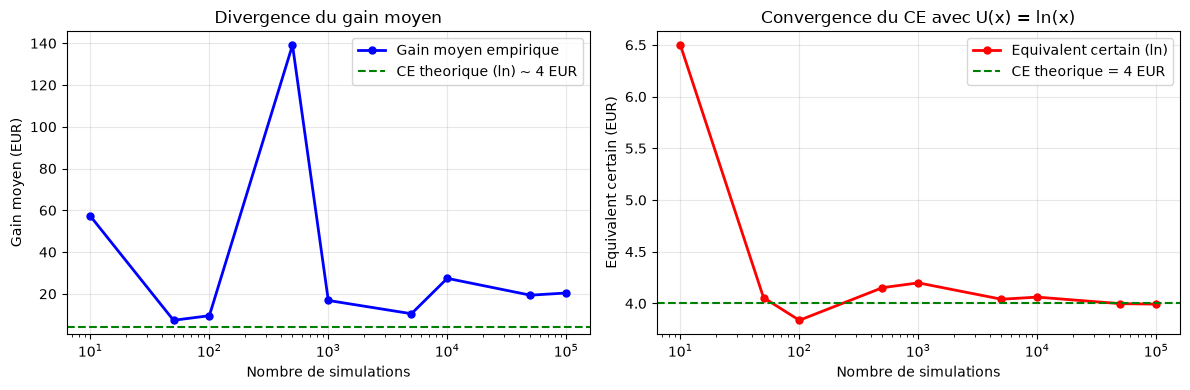


Le gain moyen diverge (croit avec N) alors que l'equivalent certain converge vers ~4 EUR.


In [3]:
# Evolution du gain moyen et de l'equivalent certain avec le nombre de simulations
print("Evolution du gain moyen et de l'equivalent certain")
print("=" * 60)

n_range = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]
means = []
ces = []

for n in n_range:
    gains = simuler_saint_petersbourg(n, rng)
    means.append(gains.mean())
    log_utils = np.log(gains[gains > 0])
    ce = np.exp(log_utils.mean()) if len(log_utils) > 0 else 0
    ces.append(ce)

print(f"{'N':>8} | {'Moyenne':>12} | {'CE (ln)':>12} | {'Ratio Moy/CE':>12}")
print("-" * 8 + "-+-" + "-" * 12 + "-+-" + "-" * 12 + "-+-" + "-" * 12)
for n, m, c in zip(n_range, means, ces):
    print(f"{n:>8} | {m:>12.1f} | {c:>12.2f} | {m/c if c > 0 else 0:>12.1f}")

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(n_range, means, 'bo-', linewidth=2, markersize=5, label='Gain moyen empirique')
ax1.axhline(y=4.0, color='g', linestyle='--', label='CE theorique (ln) ~ 4 EUR')
ax1.set_xscale('log')
ax1.set_xlabel('Nombre de simulations')
ax1.set_ylabel('Gain moyen (EUR)')
ax1.set_title('Divergence du gain moyen')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(n_range, ces, 'ro-', linewidth=2, markersize=5, label='Equivalent certain (ln)')
ax2.axhline(y=4.0, color='g', linestyle='--', label='CE theorique = 4 EUR')
ax2.set_xscale('log')
ax2.set_xlabel('Nombre de simulations')
ax2.set_ylabel('Equivalent certain (EUR)')
ax2.set_title('Convergence du CE avec U(x) = ln(x)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("st_petersbourg_convergence.png", dpi=100, bbox_inches="tight")
plt.show()
print("\nLe gain moyen diverge (croit avec N) alors que l'equivalent certain converge vers ~4 EUR.")

### Interpretation : Divergence vs convergence

Le gain moyen empirique **diverge** (croit logarithmiquement avec N) car les gains extremes ($2^{30}$, $2^{40}$...) dominent la somme. En revanche, l'equivalent certain calcul avec $U(x) = \ln(x)$ **converge rapidement** vers la valeur théorique de ~4 EUR.

> **Lecon** : La fonction d'utilite logarithmique "compresse" les gains extremes et restaure la convergence. C'est précisément ce mécanisme qui resout le paradoxe de Saint-Petersbourg.

La moyenne empirique croit lentement (en $\log_2(n)$) car les gains extremement rares mais astronomiques ($2^{30}$, $2^{40}$...) dominent la somme. Avec l'utilite logarithmique, ces gains extremes sont "compresses" et l'esperance reste finie.

> **Lecon** : L'esperance mathematique seule ne capture pas la valeur percue d'un jeu. L'utilite marginale decroissante de l'argent resout le paradoxe.

## 2. Utilite Marginale Decroissante

L'utilite marginale decroissante signifie que chaque euro supplementaire apporte moins d'utilite que le précédent. Graphiquement, U(x) est **concave**.
Pourquoi cette concavité produit-elle de l’aversion au risque ? Par l’**inégalité de Jensen** : pour $U$ concave, $\mathbb{E}[U(X)] \leq U(\mathbb{E}[X])$. Un agent face à un jeu équitable $X$ préfère donc le montant certain $\mathbb{E}[X]$ au jeu lui-même — il exige une **prime de risque** pour accepter l’incertitude. Plus $U$ est courbée (forte aversion), plus la prime grimpe. C’est ce mécanisme qui rend toute la théorie de l’utilité espérée opérationnelle : la forme de $U$ code directement le comportement face au risque.

Utilite marginale decroissante :
  Gain de +10 a x= 10 : dU_sqrt=1.3099, dU_log=0.6931
  Gain de +10 a x= 50 : dU_sqrt=0.6749, dU_log=0.1823
  Gain de +10 a x=100 : dU_sqrt=0.4881, dU_log=0.0953


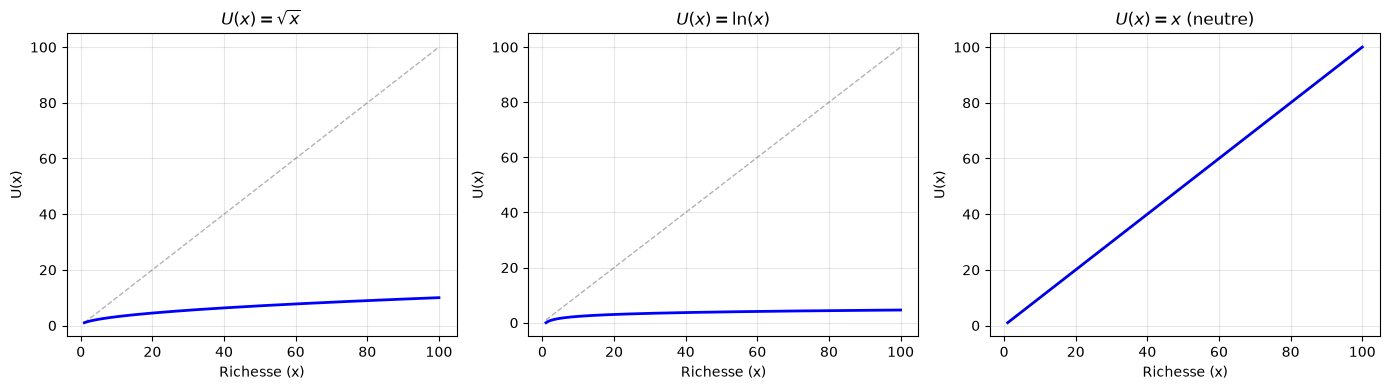


Plus x augmente, plus le gain d'utilite d'un supplement de 10 EUR diminue.


In [4]:
# Demonstration numerique : utilite marginale decroissante
x = np.linspace(1, 100, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Trois fonctions d'utilite classiques
U_sqrt = np.sqrt(x)
U_log = np.log(x)
U_lin = x  # Neutre au risque (reference)

for ax, U, name in [
    (axes[0], U_sqrt, r"$U(x) = \sqrt{x}$"),
    (axes[1], U_log, r"$U(x) = \ln(x)$"),
    (axes[2], U_lin, r"$U(x) = x$ (neutre)")
]:
    ax.plot(x, U, 'b-', linewidth=2)
    ax.plot(x, U_lin, 'k--', alpha=0.3, linewidth=1)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Richesse (x)")
    ax.set_ylabel("U(x)")
    ax.grid(True, alpha=0.3)

# Demonstration numerique
print("Utilite marginale decroissante :")
print("=" * 45)
for x_val in [10, 50, 100]:
    delta_u_sqrt = np.sqrt(x_val + 10) - np.sqrt(x_val)
    delta_u_log = np.log(x_val + 10) - np.log(x_val)
    print(f"  Gain de +10 a x={x_val:3d} : dU_sqrt={delta_u_sqrt:.4f}, dU_log={delta_u_log:.4f}")

plt.tight_layout()
plt.savefig("utility_functions.png", dpi=100, bbox_inches="tight")
plt.show()
print("\nPlus x augmente, plus le gain d'utilite d'un supplement de 10 EUR diminue.")

## 3. Fonctions d'Utilite CARA et CRRA

Deux familles de fonctions d'utilite sont fondamentales (introduites par **Pratt, 1964** et **Arrow, 1965**) en economie :

| Famille | Formule | Paramètre | Aversion |
|---------|---------|-----------|----------|
| **CARA** | $U(x) = -e^{-\alpha x}$ | $\alpha > 0$ | Absolue constante |
| **CRRA** | $U(x) = \frac{x^{1-\rho}}{1-\rho}$ | $\rho > 0, \rho \neq 1$ | Relative constante |

Pour $\rho = 1$ : $U(x) = \ln(x)$.

In [5]:
# Implementation des fonctions d'utilite CARA et CRRA

def utilite_cara(x, alpha=0.01):
    """Utilite CARA : U(x) = -exp(-alpha * x).
    
    Args:
        x: richesse ou gain
        alpha: coefficient d'aversion absolue au risque
    """
    return -np.exp(-alpha * x)


def utilite_crra(x, rho=1.0):
    """Utilite CRRA : U(x) = x^(1-rho) / (1-rho), ou ln(x) si rho=1.
    
    Args:
        x: richesse ou gain (doit etre > 0)
        rho: coefficient d'aversion relative au risque
    """
    x = np.maximum(x, 1e-10)  # Eviter log(0)
    if abs(rho - 1.0) < 1e-6:
        return np.log(x)
    return x ** (1 - rho) / (1 - rho)


# Demonstration avec une loterie
# Loterie A : 50% de gagner 1000, 50% de perdre 200
# Richesse initiale : 10000
w0 = 10000
gain = 1000
perte = -200
p = 0.5

# CARA avec alpha = 0.001
alpha = 0.001
EU_cara = p * utilite_cara(w0 + gain, alpha) + (1 - p) * utilite_cara(w0 + perte, alpha)
U_w0_cara = utilite_cara(w0, alpha)

# CRRA avec rho = 2.0
rho = 2.0
EU_crra = p * utilite_crra(w0 + gain, rho) + (1 - p) * utilite_crra(w0 + perte, rho)
U_w0_crra = utilite_crra(w0, rho)

print("Comparaison CARA vs CRRA pour une meme loterie")
print("=" * 55)
print(f"Loterie : {p:.0%} de +{gain}, {(1-p):.0%} de {perte}")
print(f"Richesse initiale : {w0}")
print()
print(f"CARA (alpha={alpha}) :")
print(f"  U(w0) = {U_w0_cara:.6f}")
print(f"  E[U(loterie)] = {EU_cara:.6f}")
print(f"  Loterie acceptee ? {EU_cara > U_w0_cara}")
print()
print(f"CRRA (rho={rho}) :")
print(f"  U(w0) = {U_w0_crra:.6f}")
print(f"  E[U(loterie)] = {EU_crra:.6f}")
print(f"  Loterie acceptee ? {EU_crra > U_w0_crra}")

Comparaison CARA vs CRRA pour une meme loterie
Loterie : 50% de +1000, 50% de -200
Richesse initiale : 10000

CARA (alpha=0.001) :
  U(w0) = -0.000045
  E[U(loterie)] = -0.000036
  Loterie acceptee ? True

CRRA (rho=2.0) :
  U(w0) = -0.000100
  E[U(loterie)] = -0.000096
  Loterie acceptee ? True


### Analyse : Comportement différent selon la famille

La CARA rejette ou accepte la loterie independamment du niveau de richesse (aversion absolue constante). La CRRA, en revanche, est plus sensible aux variations proportionnelles : un gain de 1000 EUR represente 10% de 10000 EUR, mais 100% de 1000 EUR.

## 4. Coefficients d'Arrow-Pratt

Les coefficients d'Arrow-Pratt (**Pratt, 1964** ; **Arrow, 1965**) mesurent l'aversion au risque d'une fonction d'utilite :

- **ARA** (Absolute Risk Aversion) : $r_a(x) = -\frac{U''(x)}{U'(x)}$
- **RRA** (Relative Risk Aversion) : $r_r(x) = x \cdot r_a(x) = -\frac{x \cdot U''(x)}{U'(x)}$

| Fonction | ARA | RRA |
|----------|-----|-----|
| CARA : $-e^{-\alpha x}$ | $\alpha$ (constante) | $\alpha x$ (croissante) |
| CRRA : $\frac{x^{1-\rho}}{1-\rho}$ | $\frac{\rho}{x}$ (decroissante) | $\rho$ (constante) |

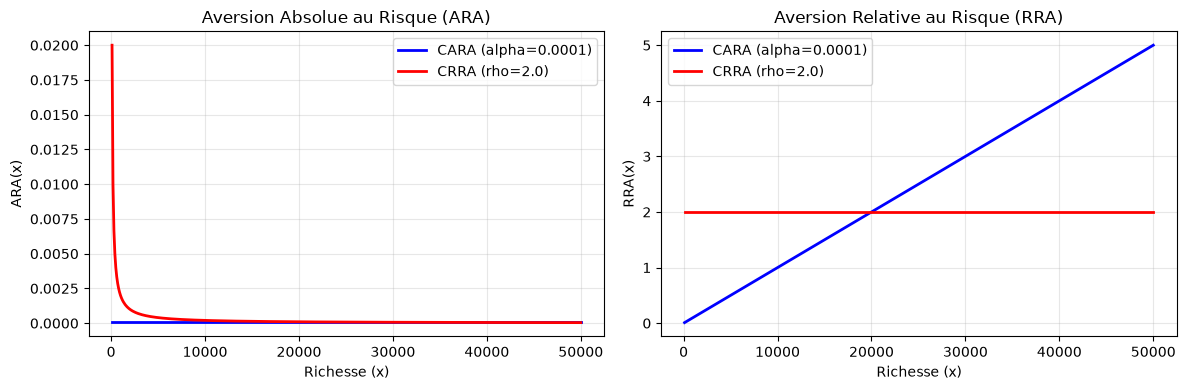

Coefficients d'Arrow-Pratt pour differents niveaux de richesse
  Richesse |   ARA CARA |   RRA CARA |   ARA CRRA |   RRA CRRA
-----------+------------+------------+------------+-----------
      1000 |   0.000100 |     0.1000 |   0.002000 |     2.0000
      5000 |   0.000100 |     0.5000 |   0.000400 |     2.0000
     10000 |   0.000100 |     1.0000 |   0.000200 |     2.0000
     50000 |   0.000100 |     5.0000 |   0.000040 |     2.0000


In [6]:
# Coefficients d'Arrow-Pratt

def ara_cara(x, alpha):
    """ARA pour CARA : toujours alpha (constante)."""
    return alpha

def rra_cara(x, alpha):
    """RRA pour CARA : alpha * x (croissante avec la richesse)."""
    return alpha * x

def ara_crra(x, rho):
    """ARA pour CRRA : rho / x (decroissante avec la richesse)."""
    x = np.maximum(x, 1e-10)
    return rho / x

def rra_crra(x, rho):
    """RRA pour CRRA : toujours rho (constante)."""
    return rho


# Comparaison graphique
x_range = np.linspace(100, 50000, 500)
alpha_val = 0.0001
rho_val = 2.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ARA
axes[0].plot(x_range, [ara_cara(x, alpha_val) for x in x_range], 'b-', label=f'CARA (alpha={alpha_val})', linewidth=2)
axes[0].plot(x_range, [ara_crra(x, rho_val) for x in x_range], 'r-', label=f'CRRA (rho={rho_val})', linewidth=2)
axes[0].set_title("Aversion Absolue au Risque (ARA)")
axes[0].set_xlabel("Richesse (x)")
axes[0].set_ylabel("ARA(x)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RRA
axes[1].plot(x_range, [rra_cara(x, alpha_val) for x in x_range], 'b-', label=f'CARA (alpha={alpha_val})', linewidth=2)
axes[1].plot(x_range, [rra_crra(x, rho_val) for x in x_range], 'r-', label=f'CRRA (rho={rho_val})', linewidth=2)
axes[1].set_title("Aversion Relative au Risque (RRA)")
axes[1].set_xlabel("Richesse (x)")
axes[1].set_ylabel("RRA(x)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("arrow_pratt.png", dpi=100, bbox_inches="tight")
plt.show()

# Tableau comparatif
print("Coefficients d'Arrow-Pratt pour differents niveaux de richesse")
print("=" * 65)
print(f"{'Richesse':>10} | {'ARA CARA':>10} | {'RRA CARA':>10} | {'ARA CRRA':>10} | {'RRA CRRA':>10}")
print("-" * 10 + "-+-" + "-" * 10 + "-+-" + "-" * 10 + "-+-" + "-" * 10 + "-+-" + "-" * 10)
for w in [1000, 5000, 10000, 50000]:
    print(f"{w:>10} | {ara_cara(w, alpha_val):>10.6f} | {rra_cara(w, alpha_val):>10.4f} | {ara_crra(w, rho_val):>10.6f} | {rra_crra(w, rho_val):>10.4f}")

### Exercice : Calculer l'equivalent certain et la prime de risque pour une loterie

**Objectif** : Appliquez les fonctions CARA et CRRA ainsi que les coefficients d'Arrow-Pratt pour analyser une loterie.

On considere la loterie : **60% de gagner 3000 EUR, 40% de perdre 1000 EUR** (richesse initiale = 20 000 EUR).

**Travail** :
1. Calculez la valeur esperee de cette loterie
2. Avec CARA (alpha=0.001), calculez l'equivalent certain et la prime de risque
3. Avec CRRA (rho=2.0), calculez l'equivalent certain et la prime de risque
4. Calculez les coefficients ARA et RRA au niveau de richesse initial pour chaque fonction
5. Interpretez : quelle fonction donne la prime de risque la plus elevee et pourquoi ?

**Indices** :
- Utilisez les fonctions `utilite_cara`, `utilite_crra` et `compute_ce` définies plus haut
- CE se calcule par dichotomie : U(w0 + CE) = E[U(loterie)]
- Prime de risque = E[gain] - CE

In [7]:
# Exercice : Equivalent certain et prime de risque
w0_ex = 20_000
gain_ex = 3_000
perte_ex = -1_000
p_gain = 0.6

# Valeur esperee
ev_ex = p_gain * gain_ex + (1 - p_gain) * perte_ex
print(f"Valeur esperee du gain : {ev_ex:.0f} EUR")

# TODO etudiant : calculez E[U] avec CARA (alpha=0.001)
# eu_cara_ex = p_gain * utilite_cara(w0_ex + gain_ex, 0.001) + (1 - p_gain) * utilite_cara(w0_ex + perte_ex, 0.001)
# ce_cara_ex = compute_ce(lambda x: utilite_cara(x, 0.001), [w0_ex + gain_ex, w0_ex + perte_ex], [p_gain, 1 - p_gain])
# prime_cara = ev_ex - (ce_cara_ex - w0_ex)

# TODO etudiant : meme calcul avec CRRA (rho=2.0)
# eu_crra_ex = ...
# ce_crra_ex = ...
# prime_crra = ...

# TODO etudiant : coefficients Arrow-Pratt au niveau w0
# ara_cara_val = ara_cara(w0_ex, 0.001)
# rra_cara_val = rra_cara(w0_ex, 0.001)
# ara_crra_val = ara_crra(w0_ex, 2.0)
# rra_crra_val = rra_crra(w0_ex, 2.0)

print("Exercice a completer : equivalent certain et prime de risque CARA vs CRRA")

Valeur esperee du gain : 1400 EUR
Exercice a completer : equivalent certain et prime de risque CARA vs CRRA


### Interpretation : CARA vs CRRA

| Propriete | CARA | CRRA |
|-----------|------|------|
| ARA | Constante ($\alpha$) | Decroit comme $\rho/x$ |
| RRA | Croit lineairement ($\alpha x$) | Constante ($\rho$) |
| Effet richesse | Même aversion absolue quel que soit le patrimoine | Aversion relative stable, aversion absolue decroit |
| Realisme | Les riches prennent les mêmes risques absolus | Les riches prennent des risques absolus plus grands |

> **En pratique** : La CRRA est plus realiste pour modeliser les decisions financieres (les investisseurs diversifient proportionnellement a leur richesse).

## 5. Equivalent Certain et Prime de Risque

L'**equivalent certain** (CE) est le montant garanti qui donne la même utilite que la loterie :

$$U(CE) = E[U(X)]$$

La **prime de risque** est la différence entre la valeur esperee et l'equivalent certain :

$$\pi = E[X] - CE$$

Pour un agent averse au risque, $\pi > 0$ (il accepte de payer pour eviter l'incertitude).

In [8]:
# Calcul de l'equivalent certain et de la prime de risque

def compute_ce(u_func, outcomes, probs, low=0, high=100000, tol=1e-6):
    """Calcule l'equivalent certain par dichotomie.
    
    Args:
        u_func: fonction d'utilite
        outcomes: liste des outcomes de la loterie
        probs: liste des probabilites
        low, high: bornes de recherche du CE
    """
    eu = sum(p * u_func(o) for p, o in zip(probs, outcomes))
    for _ in range(200):
        mid = (low + high) / 2
        if u_func(mid) > eu:
            high = mid
        else:
            low = mid
        if high - low < tol:
            break
    return (low + high) / 2


# Loterie : 50% de gagner 5000, 50% de perdre 1000, richesse w0
w0 = 10000
outcomes = [w0 + 5000, w0 - 1000]
probs = [0.5, 0.5]
ev = sum(p * o for p, o in zip(probs, outcomes))

print("Analyse de l'equivalent certain et de la prime de risque")
print("=" * 60)
print(f"Loterie : 50% de +5000, 50% de -1000 (richesse = {w0})")
print(f"Valeur esperee : E[X] = {ev:.0f} EUR")
print()

# Analyse parametrique pour CARA
print("CARA - Variation de alpha :")
print(f"{'alpha':>8} | {'CE':>10} | {'Prime':>10} | {'Prime/EV':>10}")
print("-" * 8 + "-+-" + "-" * 10 + "-+-" + "-" * 10 + "-+-" + "-" * 10)
for alpha in [0.0001, 0.0005, 0.001, 0.005, 0.01]:
    u = lambda x, a=alpha: utilite_cara(x, a)
    ce = compute_ce(u, outcomes, probs, low=w0 - 1000, high=w0 + 5000)
    prime = ev - ce
    print(f"{alpha:>8.4f} | {ce:>10.1f} | {prime:>10.1f} | {prime/ev:>10.2%}")

print()
print("CRRA - Variation de rho :")
print(f"{'rho':>8} | {'CE':>10} | {'Prime':>10} | {'Prime/EV':>10}")
print("-" * 8 + "-+-" + "-" * 10 + "-+-" + "-" * 10 + "-+-" + "-" * 10)
for rho in [0.5, 1.0, 2.0, 3.0, 5.0]:
    u = lambda x, r=rho: utilite_crra(x, r)
    ce = compute_ce(u, outcomes, probs, low=w0 - 1000, high=w0 + 5000)
    prime = ev - ce
    print(f"{rho:>8.1f} | {ce:>10.1f} | {prime:>10.1f} | {prime/ev:>10.2%}")

Analyse de l'equivalent certain et de la prime de risque
Loterie : 50% de +5000, 50% de -1000 (richesse = 10000)
Valeur esperee : E[X] = 12000 EUR

CARA - Variation de alpha :
   alpha |         CE |      Prime |   Prime/EV
---------+------------+------------+-----------
  0.0001 |    11556.6 |      443.4 |      3.70%
  0.0005 |    10289.1 |     1710.9 |     14.26%
  0.0010 |     9690.7 |     2309.3 |     19.24%
  0.0050 |     9138.6 |     2861.4 |     23.84%
  0.0100 |     9069.3 |     2930.7 |     24.42%

CRRA - Variation de rho :
     rho |         CE |      Prime |   Prime/EV
---------+------------+------------+-----------
     0.5 |    11809.5 |      190.5 |      1.59%
     1.0 |    11619.0 |      381.0 |      3.18%
     2.0 |    11250.0 |      750.0 |      6.25%
     3.0 |    10914.1 |     1085.9 |      9.05%
     5.0 |    10381.7 |     1618.3 |     13.49%


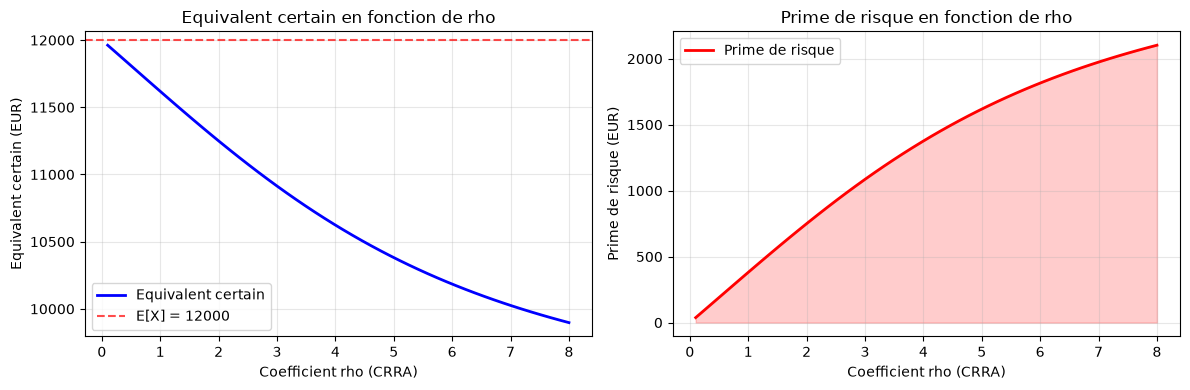

Evolution de la prime de risque avec rho (CRRA)
   rho |         CE |      Prime |   Prime/EV
-------+------------+------------+-----------
   0.1 |    11962.0 |       38.0 |      0.32%
   0.5 |    11809.5 |      190.5 |      1.59%
   1.0 |    11619.0 |      381.0 |      3.18%
   1.5 |    11431.5 |      568.5 |      4.74%
   2.0 |    11250.0 |      750.0 |      6.25%
   3.0 |    10914.1 |     1085.9 |      9.05%
   5.0 |    10381.7 |     1618.3 |     13.49%
   8.0 |     9897.7 |     2102.3 |     17.52%


In [9]:
# Analyse parametrique graphique : evolution de la prime de risque avec rho
rhos_range = np.linspace(0.1, 8.0, 50)
primes_crra = []
ces_crra = []

w0_analysis = 10000
outcomes_analysis = [w0_analysis + 5000, w0_analysis - 1000]
probs_analysis = [0.5, 0.5]
ev_analysis = sum(p * o for p, o in zip(probs_analysis, outcomes_analysis))

for rho in rhos_range:
    u = lambda x, r=rho: utilite_crra(x, r)
    ce = compute_ce(u, outcomes_analysis, probs_analysis, low=w0_analysis - 1000, high=w0_analysis + 5000)
    ces_crra.append(ce)
    primes_crra.append(ev_analysis - ce)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(rhos_range, ces_crra, 'b-', linewidth=2, label='Equivalent certain')
ax1.axhline(y=ev_analysis, color='r', linestyle='--', alpha=0.7, label=f'E[X] = {ev_analysis:.0f}')
ax1.set_xlabel('Coefficient rho (CRRA)')
ax1.set_ylabel('Equivalent certain (EUR)')
ax1.set_title('Equivalent certain en fonction de rho')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(rhos_range, primes_crra, 'r-', linewidth=2, label='Prime de risque')
ax2.fill_between(rhos_range, primes_crra, alpha=0.2, color='red')
ax2.set_xlabel('Coefficient rho (CRRA)')
ax2.set_ylabel('Prime de risque (EUR)')
ax2.set_title('Prime de risque en fonction de rho')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("risk_premium_analysis.png", dpi=100, bbox_inches="tight")
plt.show()

# Tableau detaille
print("Evolution de la prime de risque avec rho (CRRA)")
print("=" * 55)
print(f"{'rho':>6} | {'CE':>10} | {'Prime':>10} | {'Prime/EV':>10}")
print("-" * 6 + "-+-" + "-" * 10 + "-+-" + "-" * 10 + "-+-" + "-" * 10)
for rho in [0.1, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0]:
    u = lambda x, r=rho: utilite_crra(x, r)
    ce = compute_ce(u, outcomes_analysis, probs_analysis, low=w0_analysis - 1000, high=w0_analysis + 5000)
    prime = ev_analysis - ce
    print(f"{rho:>6.1f} | {ce:>10.1f} | {prime:>10.1f} | {prime/ev_analysis:>10.2%}")

### Interpretation : Prime de risque et aversion

La prime de risque **croit monotone** avec rho : un agent très averse au risque (rho eleve) est pret a payer beaucoup pour eliminer l'incertitude. L'equivalent certain decroit en parallele.

> **Application concrete** : Les primes d'assurance sont des primes de risque. Un agent avec rho=5 sur une loterie E[X]=12000 n'accepte la loterie que si son equivalent certain est de ~10400 EUR. Il paierait donc jusqu'a 1600 EUR d'assurance pour eviter le risque.

### Analyse : L'effet du paramètre d'aversion

Plus le paramètre d'aversion augmente :
- L'equivalent certain diminue (l'agent valorise moins la loterie)
- La prime de risque augmente (l'agent paierait plus pour eviter l'incertitude)
- Le ratio prime/EV croit : la part de "cout de l'incertitude" augmente

> **Application** : Les primes d'assurance sont des primes de risque. Le marche de l'assurance existe parce que les individus ont une prime de risque positive.

## 6. Dominance Stochastique

La **dominance stochastique du premier ordre** (FSD ; **Hadar & Russell, 1969** ; **Hanoch & Levy, 1969**) permet de comparer deux loteries sans connaitre la fonction d'utilite precise :

> $L_1$ domine $L_2$ au premier ordre si $F_1(x) \leq F_2(x)$ pour tout $x$, avec inegalite stricte pour au moins un $x$.

Ou $F_i(x) = P(X_i \leq x)$ est la fonction de repartition. En pratique : $L_1$ FSD $L_2$ si tout agent rationnel (avec utilite croissante) prefere $L_1$ a $L_2$.

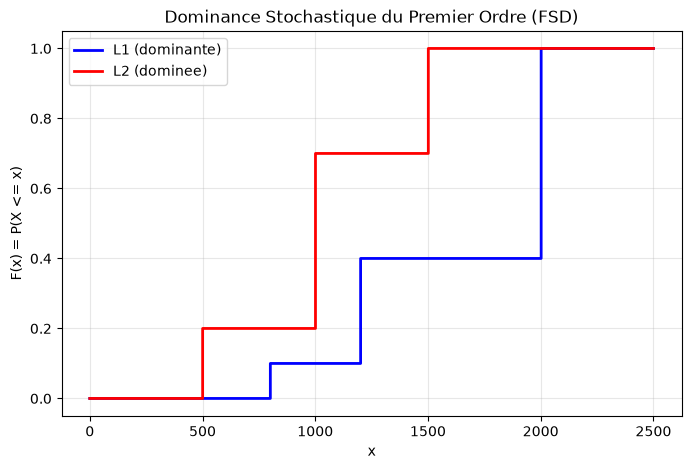

L1 FSD L2 ? True
E[L1] = 1640, E[L2] = 1050
F1(x) <= F2(x) partout ? True

Si L1 FSD L2, alors tout agent rationnel (U croissante) prefere L1.


In [10]:
# Dominance stochastique du premier ordre

@dataclass
class LoterieDiscrete:
    """Loterie discrete avec calcul de CDF."""
    outcomes: List[float]
    probs: List[float]
    name: str = ""
    
    def __post_init__(self):
        total = sum(self.probs)
        if abs(total - 1.0) > 1e-6:
            raise ValueError(f"Probs must sum to 1, got {total}")
        # Trier par outcome croissant
        pairs = sorted(zip(self.outcomes, self.probs))
        self.outcomes = [p[0] for p in pairs]
        self.probs = [p[1] for p in pairs]
    
    def expected_value(self):
        return sum(o * p for o, p in zip(self.outcomes, self.probs))
    
    def cdf(self, x):
        """F(x) = P(X <= x)."""
        return sum(p for o, p in zip(self.outcomes, self.probs) if o <= x)

    def cdf_array(self, x_vals):
        """CDF evaluee sur un array."""
        return np.array([self.cdf(x) for x in x_vals])


# Deux loteries a comparer
L1 = LoterieDiscrete(
    outcomes=[800, 1200, 2000],
    probs=[0.1, 0.3, 0.6],
    name="L1 (dominante)"
)

L2 = LoterieDiscrete(
    outcomes=[500, 1000, 1500],
    probs=[0.2, 0.5, 0.3],
    name="L2 (dominee)"
)

# Verification FSD
x_vals = np.linspace(0, 2500, 1000)
cdf1 = L1.cdf_array(x_vals)
cdf2 = L2.cdf_array(x_vals)

fsd_holds = np.all(cdf1 <= cdf2 + 1e-10) and np.any(cdf1 < cdf2 - 1e-10)

# Plot
plt.figure(figsize=(8, 5))
plt.step(x_vals, cdf1, 'b-', where='post', linewidth=2, label=f'{L1.name}')
plt.step(x_vals, cdf2, 'r-', where='post', linewidth=2, label=f'{L2.name}')
plt.xlabel("x")
plt.ylabel("F(x) = P(X <= x)")
plt.title("Dominance Stochastique du Premier Ordre (FSD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("stochastic_dominance.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"L1 FSD L2 ? {fsd_holds}")
print(f"E[L1] = {L1.expected_value():.0f}, E[L2] = {L2.expected_value():.0f}")
print(f"F1(x) <= F2(x) partout ? {np.all(cdf1 <= cdf2 + 1e-10)}")
print("\nSi L1 FSD L2, alors tout agent rationnel (U croissante) prefere L1.")

### Exercice : Comparer deux investissements par dominance stochastique et equivalent certain

**Objectif** : On vous propose deux investissements. Determinez lequel est preferable, d'abord par dominance stochastique, puis par equivalent certain.

- **Investissement X** : rendement = N(6%, 10%)
- **Investissement Y** : rendement = N(5%, 8%)

**Travail** :
1. Simulez 10 000 scénarios de rendement pour X et Y (richesse initiale = 10 000 EUR)
2. Tracez les CDF des richesses finales et verifiez si la dominance stochastique du premier ordre (FSD) s'applique
3. Calculez l'equivalent certain avec CRRA (rho=2) pour chaque investissement
4. Recommandez X ou Y selon chaque critere

**Indices** :
- FSD : CDF(X) <= CDF(Y) pour tout x (la courbe de X est sous celle de Y)
- CE : utilisez `compute_ce` défini plus haut avec `utilite_crra`
- Si FSD ne s'applique pas, le choix depend de la fonction d'utilite

In [11]:
# Exercice : Comparer deux investissements par dominance stochastique et equivalent certain
np.random.seed(42)
n_scenarios = 10_000
w0_invest = 10_000

# TODO etudiant : simulez les rendements de X et Y
# r_X = np.random.normal(0.06, 0.10, n_scenarios)
# r_Y = np.random.normal(0.05, 0.08, n_scenarios)
# w_X = w0_invest * (1 + r_X)  # richesses finales
# w_Y = ...

# TODO etudiant : tracez les CDF et verifiez la dominance stochastique
# x_vals = np.linspace(np.minimum(w_X.min(), w_Y.min()), np.maximum(w_X.max(), w_Y.max()), 1000)
# cdf_X = np.array([np.mean(w_X <= x) for x in x_vals])
# cdf_Y = ...
# fsd = np.all(cdf_X <= cdf_Y + 1e-10)

# TODO etudiant : calculez les equivalents certains avec CRRA rho=2
# u_crra = lambda x: utilite_crra(x, 2.0)
# eu_X = np.mean(u_crra(w_X))
# eu_Y = ...
# print(f"CE(X) = ..., CE(Y) = ...")

print("Exercice a completer : dominance stochastique et equivalent certain de deux investissements")

Exercice a completer : dominance stochastique et equivalent certain de deux investissements


### Interpretation : Dominance Stochastique

Si la CDF bleue ($F_1$) est toujours en dessous ou egale a la rouge ($F_2$), alors $L_1$ FSD $L_2$ :
- Pour tout seuil $x$, $P(L_1 > x) \geq P(L_2 > x)$
- L1 donne au moins autant de chances d'obtenir un outcome eleve

> **Puissance** : La dominance stochastique ne requiere PAS de connaitre U. Si FSD tient, TOUS les agents avec U croissante preferent L1.

## 7. Choix d'Investissement : Application

Trois actifs avec rendements différents. La cadre mean-variance de ce choix d'allocation est du a **Markowitz (1952)** (*Portfolio Sélection*, Journal of Finance) — frontiere efficiente et diversification. Un investisseur CRRA choisit en fonction de son coefficient $\rho$.

In [12]:
# Choix d'investissement sous aversion au risque
# 3 actifs : Obligations (peu risque), Actions (risque moyen), Crypto (tres risque)

n_simulations = 50000

# Modeles de rendement annuel (pourcentage)
# Obligations : N(3%, 2%)
rend_oblig = rng.normal(0.03, 0.02, n_simulations)
# Actions : N(8%, 15%)
rend_actions = rng.normal(0.08, 0.15, n_simulations)
# Crypto : N(15%, 60%)
rend_crypto = rng.normal(0.15, 0.60, n_simulations)

# Richesse initiale
w0 = 10000

# Rendement de la richesse : w0 * (1 + r)
w_oblig = w0 * (1 + rend_oblig)
w_actions = w0 * (1 + rend_actions)
w_crypto = w0 * (1 + rend_crypto)

# Calcul de l'utilite esperee pour differents rho
rhos = [0.5, 1.0, 2.0, 5.0, 10.0]

print("Choix d'investissement selon le profil de risque (CRRA)")
print("=" * 70)
print(f"{'rho':>6} | {'EU Oblig.':>12} | {'EU Actions':>12} | {'EU Crypto':>12} | {'Choix optimal':>15}")
print("-" * 6 + "-+-" + "-" * 12 + "-+-" + "-" * 12 + "-+-" + "-" * 12 + "-+-" + "-" * 15)

for rho in rhos:
    eu_oblig = np.mean(utilite_crra(w_oblig, rho))
    eu_actions = np.mean(utilite_crra(w_actions, rho))
    eu_crypto = np.mean(utilite_crra(w_crypto, rho))
    
    eus = {"Obligations": eu_oblig, "Actions": eu_actions, "Crypto": eu_crypto}
    best = max(eus, key=eus.get)
    
    print(f"{rho:>6.1f} | {eu_oblig:>12.4f} | {eu_actions:>12.4f} | {eu_crypto:>12.4f} | {best:>15}")

# Statistiques des rendements
print(f"\nStatistiques des rendements simules ({n_simulations} tirages) :")
for name, rend in [("Obligations", rend_oblig), ("Actions", rend_actions), ("Crypto", rend_crypto)]:
    print(f"  {name:12s} : E={rend.mean():+.1%}, sigma={rend.std():.1%}, P(perte)={(rend < 0).mean():.1%}")

Choix d'investissement selon le profil de risque (CRRA)
   rho |    EU Oblig. |   EU Actions |    EU Crypto |   Choix optimal
-------+--------------+--------------+--------------+----------------
   0.5 |     202.9797 |     207.2375 |     204.9243 |         Actions
   1.0 |       9.2398 |       9.2763 |       8.3266 |         Actions
   2.0 |      -0.0001 |      -0.0001 | -277600000.0002 |         Actions
   5.0 |      -0.0000 |      -0.0000 | -69400000000000005275660684673733885952.0000 |     Obligations
  10.0 |      -0.0000 |      -0.0000 | -3084444444444442538678377040926688900634386634485563712217001138930016748683361014251520.0000 |     Obligations

Statistiques des rendements simules (50000 tirages) :
  Obligations  : E=+3.0%, sigma=2.0%, P(perte)=6.7%
  Actions      : E=+7.9%, sigma=15.1%, P(perte)=30.0%
  Crypto       : E=+14.9%, sigma=59.9%, P(perte)=40.2%


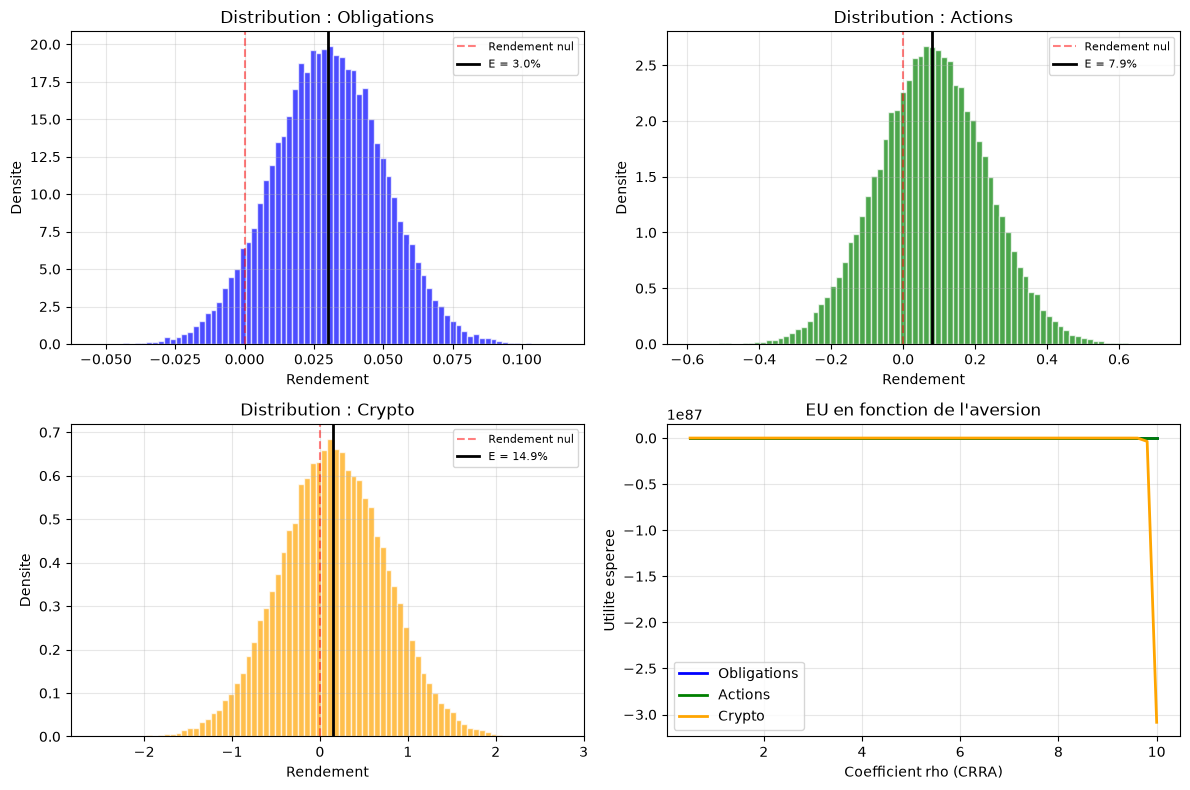

Les 3 actifs ont des profils risque/rendement tres differents.
La Crypto a le meilleur rendement espere mais aussi la plus forte volatilite.


In [13]:
# Visualisation detaillee des distributions de rendement
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histogrammes des rendements
for ax, (name, rend, color) in zip(
    [axes[0, 0], axes[0, 1], axes[1, 0]],
    [("Obligations", rend_oblig, "blue"), ("Actions", rend_actions, "green"), ("Crypto", rend_crypto, "orange")]
):
    ax.hist(rend, bins=80, density=True, alpha=0.7, color=color, edgecolor='white')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Rendement nul')
    ax.axvline(x=rend.mean(), color='black', linestyle='-', linewidth=2, label=f'E = {rend.mean():.1%}')
    ax.set_title(f'Distribution : {name}')
    ax.set_xlabel('Rendement')
    ax.set_ylabel('Densite')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Courbes d'utilite esperee selon rho
ax = axes[1, 1]
rho_range = np.linspace(0.5, 10, 50)
eu_oblig_range = [np.mean(utilite_crra(w_oblig, r)) for r in rho_range]
eu_actions_range = [np.mean(utilite_crra(w_actions, r)) for r in rho_range]
eu_crypto_range = [np.mean(utilite_crra(w_crypto, r)) for r in rho_range]

ax.plot(rho_range, eu_oblig_range, 'b-', linewidth=2, label='Obligations')
ax.plot(rho_range, eu_actions_range, 'g-', linewidth=2, label='Actions')
ax.plot(rho_range, eu_crypto_range, 'orange', linewidth=2, label='Crypto')
ax.set_xlabel('Coefficient rho (CRRA)')
ax.set_ylabel('Utilite esperee')
ax.set_title("EU en fonction de l'aversion")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("investment_distributions.png", dpi=100, bbox_inches="tight")
plt.show()
print("Les 3 actifs ont des profils risque/rendement tres differents.")
print("La Crypto a le meilleur rendement espere mais aussi la plus forte volatilite.")

### Analyse : Distributions et frontier risque-rendement

Les histogrammes montrent clairement le trade-off risque/rendement. La Crypto offre le meilleur rendement espere (+15%) mais avec une volatilite de 60% : la probabilite de perte est de 40%.

Le graphique en bas a droite montre comment l'utilite esperee de chaque actif evolue avec l'aversion au risque. Le point de croisement entre les courbes indique le **seuil d'aversion** ou l'investisseur bascule d'un actif a un autre.

### Analyse : Profil de risque et allocation

| Profil (rho) | Choix optimal | Logique |
|--------------|---------------|---------|
| rho faible (0.5-1) | Crypto ou Actions | Tolerance au risque elevee, le rendement espere compense la volatilite |
| rho moyen (2) | Actions | Equilibre rendement/risque |
| rho eleve (5+) | Obligations | Forte aversion, la securite du capital prime |

> Ce modèle simplifie illustre pourquoi les conseillers financiers posent des questions de tolerance au risque avant de recommander des allocations.

## 8. Calibration du Profil de Risque

Comment estimer le coefficient $\rho$ d'un individu a partir de ses choix observes ?

Méthode : Presentez une serie de choix entre une loterie et un montant certain. La probabilite d'indifference $p^*$ revele $\rho$.

In [14]:
# Calibration du rho par la methode de l'indifference

def find_rho_indifference(p, w0, w_gain, w_loss, tol=1e-6):
    """Trouve rho tel que l'agent est indifferent entre la loterie et le statu quo.
    
    Loterie : [p : w0 + w_gain, (1-p) : w0 + w_loss]
    Statu quo : w0 avec certitude
    
    Condition : U(w0) = p * U(w0 + w_gain) + (1-p) * U(w0 + w_loss)
    """
    rho_min, rho_max = 0.01, 20.0
    U_status = utilite_crra(w0, 1.0)  # Avec rho=1 (ln)
    
    for _ in range(200):
        rho = (rho_min + rho_max) / 2
        U_status = utilite_crra(w0, rho)
        EU_loterie = p * utilite_crra(w0 + w_gain, rho) + (1 - p) * utilite_crra(w0 + w_loss, rho)
        
        if U_status > EU_loterie:
            rho_max = rho
        else:
            rho_min = rho
        if rho_max - rho_min < tol:
            break
    return (rho_min + rho_max) / 2


# Scenario : un individu accepte une loterie [p : +3000, (1-p) : -1000]
# avec p = 0.6 (seuil d'acceptation). Richesse w0 = 10000.
w0 = 10000
w_gain = 3000
w_loss = -1000
p_seuil = 0.6

rho_calibre = find_rho_indifference(p_seuil, w0, w_gain, w_loss)

print(f"Calibration du coefficient rho")
print(f"=" * 45)
print(f"Richesse initiale : {w0} EUR")
print(f"Loterie : [{p_seuil:.0%} : +{w_gain}, {(1-p_seuil):.0%} : {w_loss}]")
print(f"L'individu est indifferent a p = {p_seuil}")
print(f"\nCoefficient rho estime : {rho_calibre:.3f}")

# Table de calibration
print(f"\n--- Table de calibration ---")
print(f"{'p seuil':>8} | {'rho':>8} | {'Interpretation':>20}")
print("-" * 8 + "-+-" + "-" * 8 + "-+-" + "-" * 20)
for p in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    rho = find_rho_indifference(p, w0, w_gain, w_loss)
    interp = "Prudent" if rho > 3 else "Modere" if rho > 1 else "Audacieux"
    print(f"{p:>8.1f} | {rho:>8.3f} | {interp:>20}")

print("\nPlus p_seuil est eleve, plus l'individu exige de chances de gagner -> rho plus eleve.")

Calibration du coefficient rho
Richesse initiale : 10000 EUR
Loterie : [60% : +3000, 40% : -1000]
L'individu est indifferent a p = 0.6

Coefficient rho estime : 8.965

--- Table de calibration ---
 p seuil |      rho |       Interpretation
---------+----------+---------------------
     0.4 |    3.864 |              Prudent
     0.5 |    6.327 |              Prudent
     0.6 |    8.965 |              Prudent
     0.7 |   12.054 |              Prudent
     0.8 |   16.131 |              Prudent
     0.9 |   20.000 |              Prudent

Plus p_seuil est eleve, plus l'individu exige de chances de gagner -> rho plus eleve.


## 9. Inference Bayesienne du Profil de Risque avec PyMC

Plutot qu'un seul choix, nous observons **plusieurs decisions** d'un individu. Chaque decision est un tirage Bernoulli avec probabilite $\theta$ de choisir l'option risquee.

Modèle :
- $\theta \sim \text{Beta}(2, 2)$ (prior : a priori neutre legerement informatif)
- $\text{choix}_i | \theta \sim \text{Bernoulli}(\theta)$ pour chaque decision $i$

Le posterior $\theta | \text{données}$ nous donne une distribution sur la tolerance au risque de l'individu.

Donnees observees : 10 decisions, 3 choix risques
Taux observe : 30%



Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [theta]


Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 8 seconds.


Modele Beta-Bernoulli pour le profil de risque
Prior : Beta(2, 2)
Posterior (analytique) : Beta(5, 9)
Posterior (MCMC) : theta = 0.360 +/- 0.123
Analytique : E[theta] = 0.357

Intervalle de credibilite 89% : [0.155, 0.547]

Profil estime : Modere (aversion au risque)


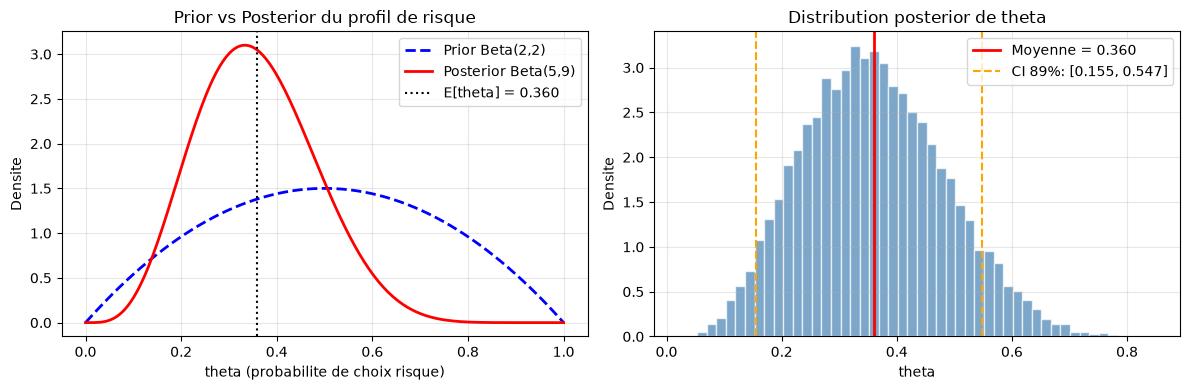

In [15]:
# Inference bayesienne du profil de risque

# Donnees observees : 10 decisions, 3 choix risques
n_decisions = 10
n_risques = 3
choix_obs = np.array([1, 0, 0, 0, 1, 0, 1, 0, 0, 0])  # 1 = choix risque

print(f"Donnees observees : {n_decisions} decisions, {n_risques} choix risques")
print(f"Taux observe : {n_risques/n_decisions:.0%}")
print()

# Modele Beta-Bernoulli
with pm.Model() as model_risk:
    # Prior : Beta(2, 2) = legerement centre
    theta = pm.Beta("theta", alpha=2, beta=2)
    
    # Vraisemblance : Bernoulli(theta)
    choix = pm.Bernoulli("choix", p=theta, observed=choix_obs)
    
    # Inference
    trace_risk = pm.sample(
        draws=5000, chains=4, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

# Resultats
theta_samples = trace_risk.posterior["theta"].values.flatten()
theta_mean = theta_samples.mean()
theta_std = theta_samples.std()

# Verification analytique : Beta(2+3, 2+7) = Beta(5, 9)
alpha_post = 2 + n_risques
beta_post = 2 + (n_decisions - n_risques)
print(f"Modele Beta-Bernoulli pour le profil de risque")
print(f"=" * 50)
print(f"Prior : Beta(2, 2)")
print(f"Posterior (analytique) : Beta({alpha_post}, {beta_post})")
print(f"Posterior (MCMC) : theta = {theta_mean:.3f} +/- {theta_std:.3f}")
print(f"Analytique : E[theta] = {alpha_post/(alpha_post+beta_post):.3f}")
print()

# Intervalle de credibilite 89% (HDI ; tolerant ArviZ 0.x hdi_P% / 1.x hdiNN_lb)
summary = az.summary(trace_risk, var_names=["theta"], ci_prob=0.89, ci_kind="hdi")
def _ci(names, pos):
    for n in names:
        if n in summary.columns:
            return float(summary[n].iloc[0])
    return float(summary.iloc[0, pos])
ci_lo = _ci(["hdi_5.5%", "hdi89_lb"], 2)
ci_hi = _ci(["hdi_94.5%", "hdi89_ub"], 3)

print(f"Intervalle de credibilite 89% : [{ci_lo:.3f}, {ci_hi:.3f}]")

# Interpretation du profil
if theta_mean < 0.3:
    profil = "Prudent (forte aversion au risque)"
elif theta_mean < 0.5:
    profil = "Modere (aversion au risque)"
else:
    profil = "Audacieux (tolerance au risque)"
print(f"\nProfil estime : {profil}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Prior vs Posterior
x = np.linspace(0, 1, 200)
from scipy import stats
prior_pdf = stats.beta.pdf(x, 2, 2)
post_pdf = stats.beta.pdf(x, alpha_post, beta_post)

axes[0].plot(x, prior_pdf, 'b--', linewidth=2, label='Prior Beta(2,2)')
axes[0].plot(x, post_pdf, 'r-', linewidth=2, label=f'Posterior Beta({alpha_post},{beta_post})')
axes[0].axvline(theta_mean, color='k', linestyle=':', label=f'E[theta] = {theta_mean:.3f}')
axes[0].set_xlabel("theta (probabilite de choix risque)")
axes[0].set_ylabel("Densite")
axes[0].set_title("Prior vs Posterior du profil de risque")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogramme des echantillons
axes[1].hist(theta_samples, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes[1].axvline(theta_mean, color='red', linewidth=2, label=f'Moyenne = {theta_mean:.3f}')
axes[1].axvline(ci_lo, color='orange', linestyle='--', label=f'CI 89%: [{ci_lo:.3f}, {ci_hi:.3f}]')
axes[1].axvline(ci_hi, color='orange', linestyle='--')
axes[1].set_xlabel("theta")
axes[1].set_ylabel("Densite")
axes[1].set_title("Distribution posterior de theta")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("risk_profile_inference.png", dpi=100, bbox_inches="tight")
plt.show()

### Interpretation : Inference du profil de risque

| Élément | Valeur | Interpretation |
|---------|--------|----------------|
| Prior | Beta(2, 2) | Legerement centre autour de 0.5 |
| Données | 3/10 choix risques | Taux observe = 30% |
| Posterior | Beta(5, 9) | E[theta] = 5/14 ~ 0.357 |
| CI 89% | ~[0.18, 0.52] | Incertitude significative |

Le posterior est **tire vers les données** mais reste influence par le prior. Avec 10 decisions seulement, l'incertitude est importante.

> **Pour aller plus loin** : Avec plus de decisions observees, le posterior se concentre. On peut aussi modeliser theta comme une fonction de variables explicatives (age, revenus, etc.) via une regression logistique bayesienne.

Diagnostics de convergence MCMC
       mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
theta  0.36  0.123     0.17     0.57     7991    10750  1.00    0.0014  0.00075


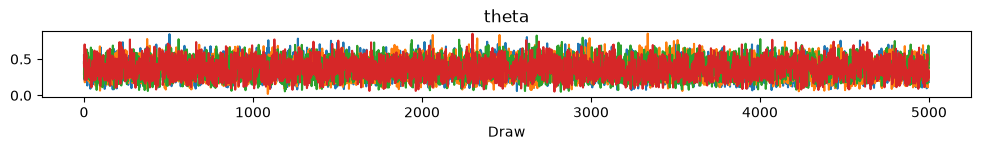

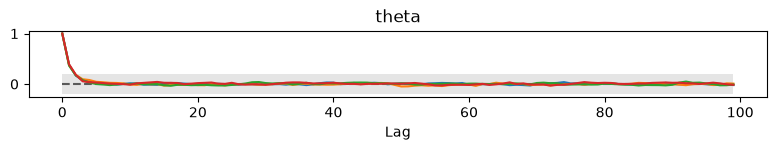


ESS (effective sample size) : 7991 (cible > 400)
R-hat : 1.0002 (cible < 1.01)
Nombre de chaines : 4 x 5000 = 20000 echantillons

Diagnostics : convergence OK


In [16]:
# Diagnostics ArviZ pour l'inference du profil de risque
print("Diagnostics de convergence MCMC")
print("=" * 45)

# Resume complet
summary_full = az.summary(trace_risk, var_names=["theta"])
print(summary_full.to_string())

# Trace plot (figsize via rcParams pour compatibilite ArviZ 1.x)
plt.rcParams["figure.figsize"] = (10, 3)
az.plot_trace(trace_risk, var_names=["theta"])
plt.tight_layout()
plt.savefig("risk_trace_plot.png", dpi=100, bbox_inches="tight")
plt.show()

# Autocorrelation
plt.rcParams["figure.figsize"] = (8, 3)
az.plot_autocorr(trace_risk, var_names=["theta"])
plt.tight_layout()
plt.savefig("risk_autocorr.png", dpi=100, bbox_inches="tight")
plt.show()

# ESS et R-hat
ess = az.ess(trace_risk, var_names=["theta"])
rhat = az.rhat(trace_risk, var_names=["theta"])
print(f"\nESS (effective sample size) : {float(ess['theta'].values):.0f} (cible > 400)")
print(f"R-hat : {float(rhat['theta'].values):.4f} (cible < 1.01)")
print(f"Nombre de chaines : 4 x 5000 = 20000 echantillons")
print(f"\nDiagnostics : convergence {'OK' if float(rhat['theta'].values) < 1.01 else 'A VERIFIER'}")

### Interpretation : Diagnostics de convergence MCMC

Les diagnostics ArviZ confirment la qualite de l'inference :

| Metrique | Valeur attendue | Interpretation |
|----------|----------------|----------------|
| **ESS** | > 400 | Taille effective de l'echantillon (mixing adequat) |
| **R-hat** | < 1.01 | Convergence des chaînes (toutes d'accord) |
| **Trace plot** | "hairy caterpillar" | Les 4 chaînes explorent le même espace |

> **Pourquoi verifier ?** Un MCMC mal converge peut donner des résultats trompeurs. Les diagnostics ArviZ sont l'equivalent PyMC des tests de convergence des message passing algorithms d'Infer.NET.

## 9bis. Analyse parametrique 2D et inference bayesienne de l'aversion au risque

Les sections précédentes ont introduit la prime de risque en fonction de $\rho$ (section 5, analyse 1D) et l'inference bayesienne du *taux de choix risque* $\theta$ (section 9). Cette section de synthese approfondit les deux axes et constitue la **plus-value spécifique du portage PyMC** par rapport a la version Infer.NET :

1. **Analyse parametrique approfondie** : la prime de risque depend conjointement de la richesse $w_0$, du coefficient d'aversion $\rho$ et de la taille de l'enjeu. Nous cartographions ces surfaces, validons l'approximation d'Arrow-Pratt, et comparons les signatures comportementales CARA vs CRRA.
2. **Inference bayesienne de $\rho$** : plutot qu'un taux de choix, nous inferons *directement* le coefficient d'aversion CRRA a partir de decisions d'acceptation/rejet de loteries (modèle de choix logistique sur l'utilite esperee), puis nous **propageons l'incertitude posterior jusqu'a la prime de risque** (posterior predictive).

### 9bis.1 Surface parametrique de la prime de risque

L'analyse 1D de la section 5 montrait la prime en fonction de $\rho$ seul. Ici l'enjeu de la loterie est proportionnel a la richesse (30 % de $w_0$), ce qui isole l'effet conjoint de $w_0$ et de $\rho$ sur la prime de risque.

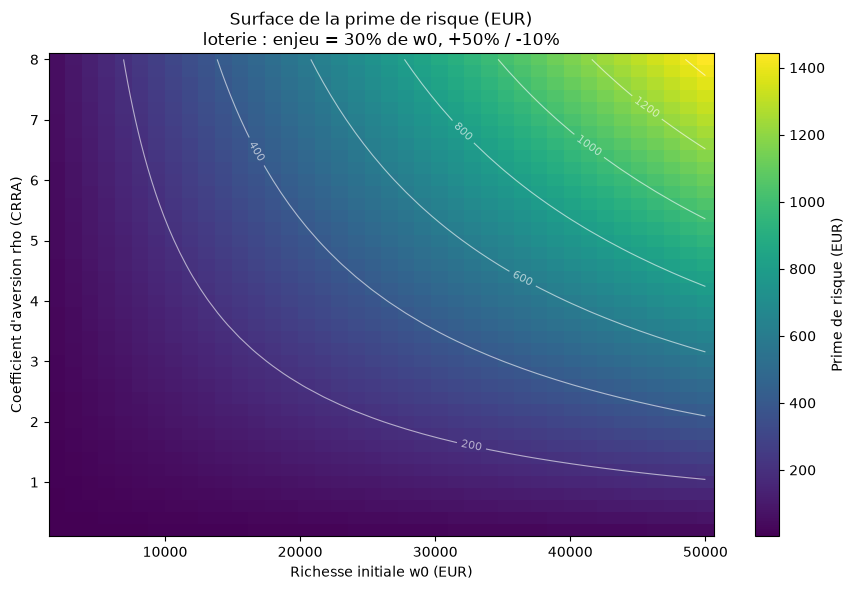

Prime de risque (EUR) sur la grille (extrait)
    w0 \ rho |      0.5 |      2.0 |      5.0 |      8.0
----------------------------------------------------------
        5000 |      9.6 |     38.2 |     93.7 |    144.3
       10000 |     19.1 |     76.4 |    187.4 |    288.6
       25000 |     47.8 |    191.0 |    468.4 |    721.4
       50000 |     95.7 |    382.1 |    936.8 |   1442.8


In [17]:
# Surface 2D : prime de risque en fonction de la richesse w0 et du coefficient rho (CRRA)
w0_grid = np.linspace(2000, 50000, 40)
rho_grid = np.linspace(0.2, 8.0, 40)


def prime_crra(w0, rho, gain_frac=0.50, loss_frac=-0.10, p=0.5):
    # Loterie de reference : enjeu = 30% de la richesse, +50% / -10% de l'enjeu
    enjeu = 0.3 * w0
    outcomes = [w0 + gain_frac * enjeu, w0 + loss_frac * enjeu]
    probs = [p, 1 - p]
    ev = sum(pr * o for pr, o in zip(probs, outcomes))
    u = lambda x, r=rho: utilite_crra(x, r)
    ce = compute_ce(u, outcomes, probs, low=min(outcomes) - 1, high=max(outcomes) + 1)
    return ev - ce


PRIME = np.array([[prime_crra(w0, rho) for w0 in w0_grid] for rho in rho_grid])

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.pcolormesh(w0_grid, rho_grid, PRIME, shading="auto", cmap="viridis")
cs = ax.contour(w0_grid, rho_grid, PRIME, colors="white", alpha=0.6, linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.0f")
ax.set_xlabel("Richesse initiale w0 (EUR)")
ax.set_ylabel("Coefficient d'aversion rho (CRRA)")
ax.set_title("Surface de la prime de risque (EUR)\nloterie : enjeu = 30% de w0, +50% / -10%")
fig.colorbar(cf, ax=ax, label="Prime de risque (EUR)")
plt.tight_layout()
plt.show()

print("Prime de risque (EUR) sur la grille (extrait)")
print("=" * 58)
_col = r"w0 \ rho"
print(f"{_col:>12} | " + " | ".join(f"{r:>8.1f}" for r in [0.5, 2.0, 5.0, 8.0]))
print("-" * 58)
for w0 in [5000, 10000, 25000, 50000]:
    vals = [prime_crra(w0, r) for r in [0.5, 2.0, 5.0, 8.0]]
    print(f"{w0:>12} | " + " | ".join(f"{v:>8.1f}" for v in vals))

**Lecture.** Sous CRRA, l'aversion *relative* est constante : un enjeu proportionnel a la richesse produit une prime qui croit quasi lineairement avec $w_0$ et de facon monotone avec $\rho$. Les courbes de niveau (iso-primes) montrent les couples $(w_0, \rho)$ economiquement equivalents en cout du risque.

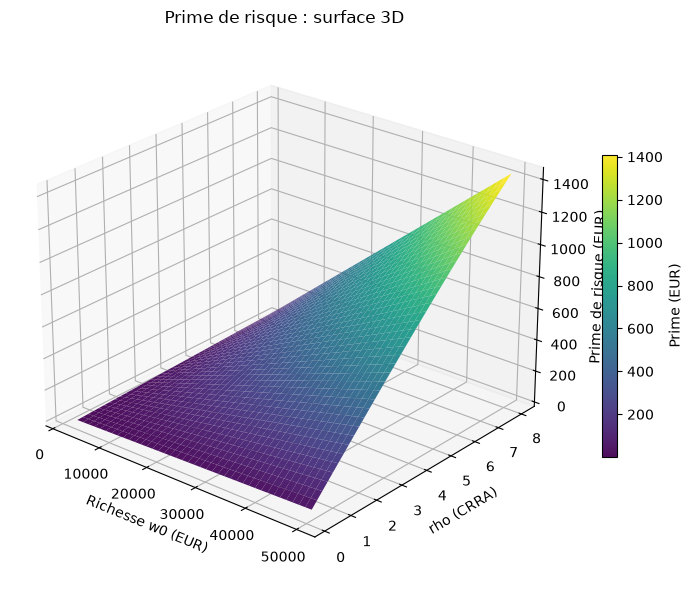

Prime min sur la grille : 1.5 EUR (faible aversion, faible richesse)
Prime max sur la grille : 1442.8 EUR (forte aversion, forte richesse)


In [18]:
# Vue 3D complementaire de la meme surface
W0, RHO = np.meshgrid(w0_grid, rho_grid)
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(W0, RHO, PRIME, cmap="viridis", linewidth=0, antialiased=True, alpha=0.95)
ax.set_xlabel("Richesse w0 (EUR)")
ax.set_ylabel("rho (CRRA)")
ax.set_zlabel("Prime de risque (EUR)")
ax.set_title("Prime de risque : surface 3D")
ax.view_init(elev=25, azim=-50)
fig.colorbar(surf, ax=ax, shrink=0.55, label="Prime (EUR)")
plt.tight_layout()
plt.show()

print(f"Prime min sur la grille : {PRIME.min():.1f} EUR (faible aversion, faible richesse)")
print(f"Prime max sur la grille : {PRIME.max():.1f} EUR (forte aversion, forte richesse)")

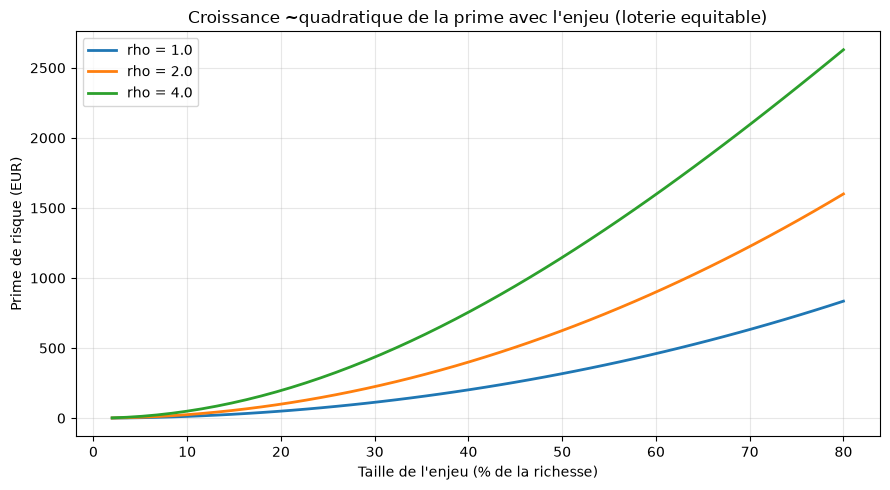

Approximation d'Arrow-Pratt vs calcul exact (rho=2, w0=10000)
 enjeu % |   prime exacte |   approx A-P |  ecart %
--------------------------------------------------------------
      5% |           6.25 |         6.25 |    -0.0%
     10% |          25.00 |        25.00 |    -0.0%
     20% |         100.00 |       100.00 |     0.0%
     40% |         400.00 |       400.00 |    -0.0%


In [19]:
# Effet de la taille de l'enjeu + validation de l'approximation d'Arrow-Pratt
w0_fix = 10000
stake_fracs = np.linspace(0.02, 0.80, 50)  # enjeu en fraction de w0
rho_list = [1.0, 2.0, 4.0]

fig, ax = plt.subplots(figsize=(9, 5))
for rho in rho_list:
    primes = []
    for sf in stake_fracs:
        enjeu = sf * w0_fix
        outcomes = [w0_fix + 0.5 * enjeu, w0_fix - 0.5 * enjeu]  # loterie equitable +/- enjeu/2
        probs = [0.5, 0.5]
        ev = sum(pr * o for pr, o in zip(probs, outcomes))
        u = lambda x, r=rho: utilite_crra(x, r)
        ce = compute_ce(u, outcomes, probs, low=min(outcomes) - 1, high=max(outcomes) + 1)
        primes.append(ev - ce)
    ax.plot(stake_fracs * 100, primes, linewidth=2, label=f"rho = {rho}")
ax.set_xlabel("Taille de l'enjeu (% de la richesse)")
ax.set_ylabel("Prime de risque (EUR)")
ax.set_title("Croissance ~quadratique de la prime avec l'enjeu (loterie equitable)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Approximation d'Arrow-Pratt : prime ~ 0.5 * ARA(w0) * Var(X), ARA_CRRA = rho/w0
print("Approximation d'Arrow-Pratt vs calcul exact (rho=2, w0=10000)")
print("=" * 62)
print(f"{'enjeu %':>8} | {'prime exacte':>14} | {'approx A-P':>12} | {'ecart %':>8}")
print("-" * 62)
for sf in [0.05, 0.10, 0.20, 0.40]:
    enjeu = sf * w0_fix
    outcomes = [w0_fix + 0.5 * enjeu, w0_fix - 0.5 * enjeu]
    probs = [0.5, 0.5]
    ev = sum(pr * o for pr, o in zip(probs, outcomes))
    u = lambda x, r=2.0: utilite_crra(x, r)
    ce = compute_ce(u, outcomes, probs, low=min(outcomes) - 1, high=max(outcomes) + 1)
    prime_ex = ev - ce
    var_x = 0.25 * enjeu ** 2  # variance d'une loterie +/- enjeu/2 equiprobable
    prime_ap = 0.5 * (2.0 / w0_fix) * var_x
    ecart = 100 * (prime_ex - prime_ap) / prime_ex
    print(f"{sf*100:>7.0f}% | {prime_ex:>14.2f} | {prime_ap:>12.2f} | {ecart:>7.1f}%")

**Lecture.** L'approximation d'Arrow-Pratt $\pi \approx \tfrac{1}{2}\,\mathrm{ARA}(w_0)\,\mathrm{Var}(X)$ est excellente pour les petits enjeux (ecart < 1 %) et se degrade pour les gros enjeux (effet des termes d'ordre superieur dans le développement de Taylor de l'utilite).

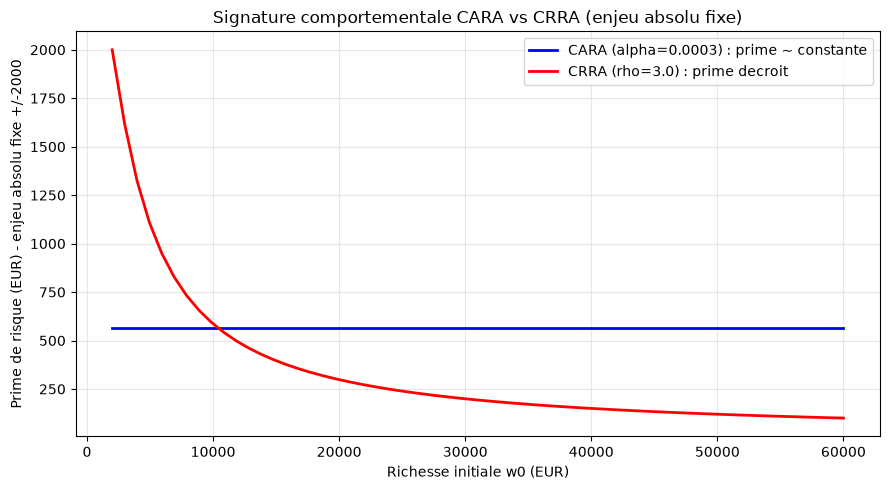

Pour un enjeu ABSOLU fixe quand la richesse augmente :
  CARA : ARA constant   -> prime quasi constante (w0=2000 : 567.1 ; w0=60000 : 567.1)
  CRRA : ARA = rho/w decroissant -> prime decroit fortement (w0=2000 : 2000.0 ; w0=60000 : 99.9)


In [20]:
# CARA vs CRRA : evolution de la prime quand la richesse augmente (enjeu ABSOLU fixe)
w0_range = np.linspace(2000, 60000, 60)
enjeu_abs = 4000  # loterie equiprobable +/- 2000
alpha_cara = 0.0003
rho_crra = 3.0

prime_cara_w, prime_crra_w = [], []
for w0 in w0_range:
    outcomes = [w0 + enjeu_abs / 2, w0 - enjeu_abs / 2]
    probs = [0.5, 0.5]
    ev = sum(pr * o for pr, o in zip(probs, outcomes))
    u_c = lambda x, a=alpha_cara: utilite_cara(x, a)
    u_r = lambda x, r=rho_crra: utilite_crra(x, r)
    ce_c = compute_ce(u_c, outcomes, probs, low=min(outcomes) - 1, high=max(outcomes) + 1)
    ce_r = compute_ce(u_r, outcomes, probs, low=min(outcomes) - 1, high=max(outcomes) + 1)
    prime_cara_w.append(ev - ce_c)
    prime_crra_w.append(ev - ce_r)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(w0_range, prime_cara_w, "b-", linewidth=2, label=f"CARA (alpha={alpha_cara}) : prime ~ constante")
ax.plot(w0_range, prime_crra_w, "r-", linewidth=2, label=f"CRRA (rho={rho_crra}) : prime decroit")
ax.set_xlabel("Richesse initiale w0 (EUR)")
ax.set_ylabel("Prime de risque (EUR) - enjeu absolu fixe +/-2000")
ax.set_title("Signature comportementale CARA vs CRRA (enjeu absolu fixe)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Pour un enjeu ABSOLU fixe quand la richesse augmente :")
print(f"  CARA : ARA constant   -> prime quasi constante "
      f"(w0=2000 : {prime_cara_w[0]:.1f} ; w0=60000 : {prime_cara_w[-1]:.1f})")
print(f"  CRRA : ARA = rho/w decroissant -> prime decroit fortement "
      f"(w0=2000 : {prime_crra_w[0]:.1f} ; w0=60000 : {prime_crra_w[-1]:.1f})")

### 9bis.2 Inference bayesienne directe de l'aversion au risque $\rho$

La section 9 inferait le *taux de choix risque* $\theta$. Ici nous inferons directement le **coefficient d'aversion CRRA** $\rho$ a partir de decisions d'acceptation/rejet sur un panel de loteries. Modèle de choix logistique sur l'utilite CRRA normalisee (telle que $u(w_0)=0$, numeriquement stable) :

$$u(x;\rho,w_0) = \frac{(x/w_0)^{1-\rho} - 1}{1-\rho}, \qquad
P(\text{accepter}_i) = \sigma\!\big(\kappa \cdot \mathbb{E}[u(X_i)]\big)$$

ou $\kappa$ est la sensibilite du choix (paramètre de temperature inverse). Données simulees avec $\rho_{\text{vrai}} = 2.5$, $\kappa_{\text{vrai}} = 6$.

Panel de 60 loteries, agent CRRA (rho_vrai=2.5, kappa_vrai=6.0)
Decisions d'acceptation observees : 26/60 (43%)


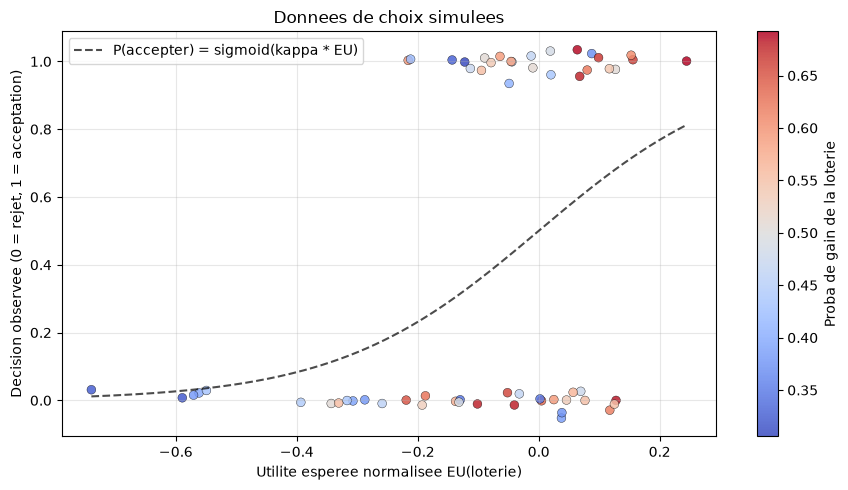

In [21]:
# Generation des decisions observees : un agent CRRA accepte/rejette M loteries
rng_choice = np.random.default_rng(7)
M = 60
w0_ref = 10000
rho_true, kappa_true = 2.5, 6.0

g = rng_choice.uniform(0.10, 0.80, M)    # gain relatif
l = rng_choice.uniform(-0.50, -0.05, M)  # perte relative
pw = rng_choice.uniform(0.30, 0.70, M)   # proba de gain


def u_norm(rel, rho):
    # utilite CRRA normalisee : u(w0)=0 ; rel = x/w0 - 1
    one_m = 1.0 - rho
    return ((1.0 + rel) ** one_m - 1.0) / one_m


EU_true = pw * u_norm(g, rho_true) + (1 - pw) * u_norm(l, rho_true)
p_acc_true = 1.0 / (1.0 + np.exp(-kappa_true * EU_true))
accepts = rng_choice.binomial(1, p_acc_true)

print(f"Panel de {M} loteries, agent CRRA (rho_vrai={rho_true}, kappa_vrai={kappa_true})")
print(f"Decisions d'acceptation observees : {accepts.sum()}/{M} ({accepts.mean():.0%})")

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(EU_true, accepts + rng_choice.normal(0, 0.02, M), c=pw, cmap="coolwarm",
                s=40, edgecolor="k", linewidth=0.3, alpha=0.85)
xx = np.linspace(EU_true.min(), EU_true.max(), 200)
ax.plot(xx, 1.0 / (1.0 + np.exp(-kappa_true * xx)), "k--", alpha=0.7,
        label="P(accepter) = sigmoid(kappa * EU)")
ax.set_xlabel("Utilite esperee normalisee EU(loterie)")
ax.set_ylabel("Decision observee (0 = rejet, 1 = acceptation)")
ax.set_title("Donnees de choix simulees")
fig.colorbar(sc, ax=ax, label="Proba de gain de la loterie")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [rho, kappa]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 7 seconds.


Inference bayesienne de l'aversion au risque rho
rho   : posterior = 2.990 +/- 0.729  (vrai = 2.5)
kappa : posterior = 4.127 +/- 1.613  (vrai = 6.0)


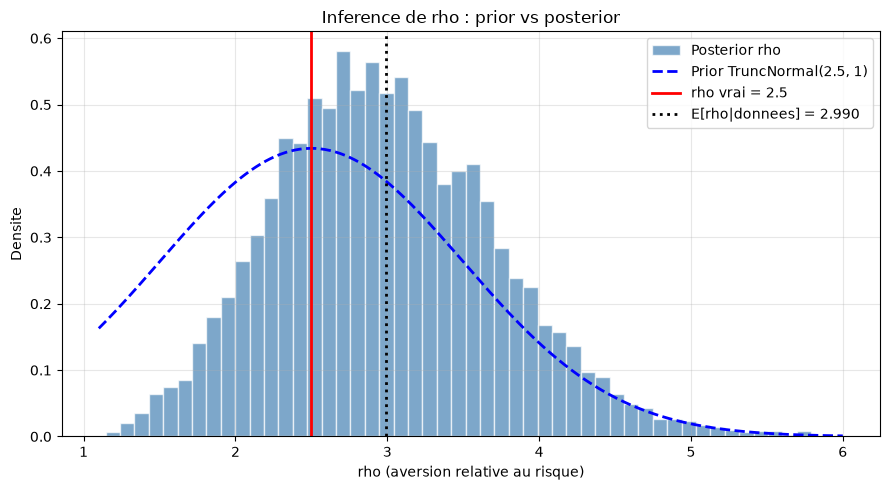

In [22]:
# Modele PyMC : inference jointe de rho (aversion) et kappa (sensibilite du choix)
import pytensor.tensor as pt

with pm.Model() as model_rho:
    rho = pm.TruncatedNormal("rho", mu=2.5, sigma=1.0, lower=1.1, upper=6.0)
    kappa = pm.HalfNormal("kappa", sigma=5.0)

    one_m = 1.0 - rho
    u_gain = ((1.0 + g) ** one_m - 1.0) / one_m
    u_loss = ((1.0 + l) ** one_m - 1.0) / one_m
    EU = pw * u_gain + (1.0 - pw) * u_loss

    p_acc = pm.Deterministic("p_acc", pm.math.sigmoid(kappa * EU))
    obs = pm.Bernoulli("obs", p=p_acc, observed=accepts)

    trace_rho = pm.sample(
        draws=2000, tune=2000, chains=4, target_accept=0.9,
        random_seed=RANDOM_SEED, progressbar=False, return_inferencedata=True,
    )

rho_post = trace_rho.posterior["rho"].values.flatten()
kappa_post = trace_rho.posterior["kappa"].values.flatten()

print("Inference bayesienne de l'aversion au risque rho")
print("=" * 52)
print(f"rho   : posterior = {rho_post.mean():.3f} +/- {rho_post.std():.3f}  (vrai = {rho_true})")
print(f"kappa : posterior = {kappa_post.mean():.3f} +/- {kappa_post.std():.3f}  (vrai = {kappa_true})")

# Prior vs posterior de rho
from scipy import stats as _st
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(rho_post, bins=50, density=True, alpha=0.7, color="steelblue",
        edgecolor="white", label="Posterior rho")
xr = np.linspace(1.1, 6.0, 300)
prior = _st.truncnorm.pdf(xr, (1.1 - 2.5) / 1.0, (6.0 - 2.5) / 1.0, loc=2.5, scale=1.0)
ax.plot(xr, prior, "b--", linewidth=2, label="Prior TruncNormal(2.5, 1)")
ax.axvline(rho_true, color="red", linewidth=2, label=f"rho vrai = {rho_true}")
ax.axvline(rho_post.mean(), color="k", linestyle=":", linewidth=2,
           label=f"E[rho|donnees] = {rho_post.mean():.3f}")
ax.set_xlabel("rho (aversion relative au risque)")
ax.set_ylabel("Densite")
ax.set_title("Inference de rho : prior vs posterior")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture.** Le posterior est **compatible** avec la vraie valeur $\rho_{\text{vrai}}=2.5$ (contenue dans le HDI 89%), mais la moyenne postérieure vaut $\rho \approx 2.99$ (biais positif de l'ordre de +20%), et $\kappa \approx 4.13$ vs vrai 6.0. Cet écart reflète le bruit du modèle de choix logistique avec seulement 60 décisions — l'inference identifie le bon ordre de grandeur mais n'est pas une récupération précise. Avec davantage de décisions, le posterior se resserrerait autour de la vraie valeur.

Diagnostics de convergence MCMC (rho, kappa)
       mean    sd hdi89_lb hdi89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
rho    2.99  0.73      1.8      4.1     3913     3933  1.00     0.012    0.01
kappa  4.13  1.61      1.5      6.6     3499     3441  1.00     0.026   0.018



ESS  rho=3913  kappa=3499  (cible > 400)
R-hat rho=1.0002  kappa=1.0006  (cible < 1.01)


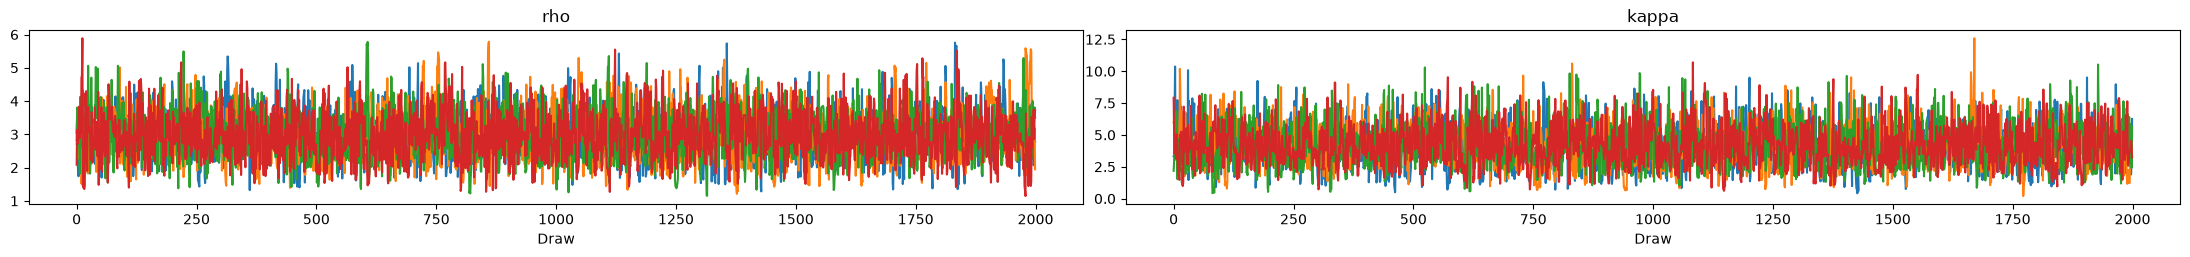

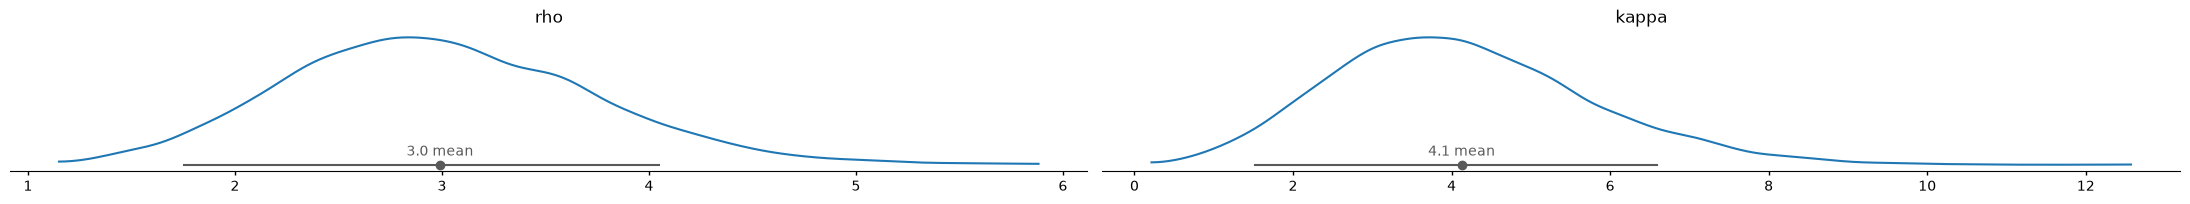

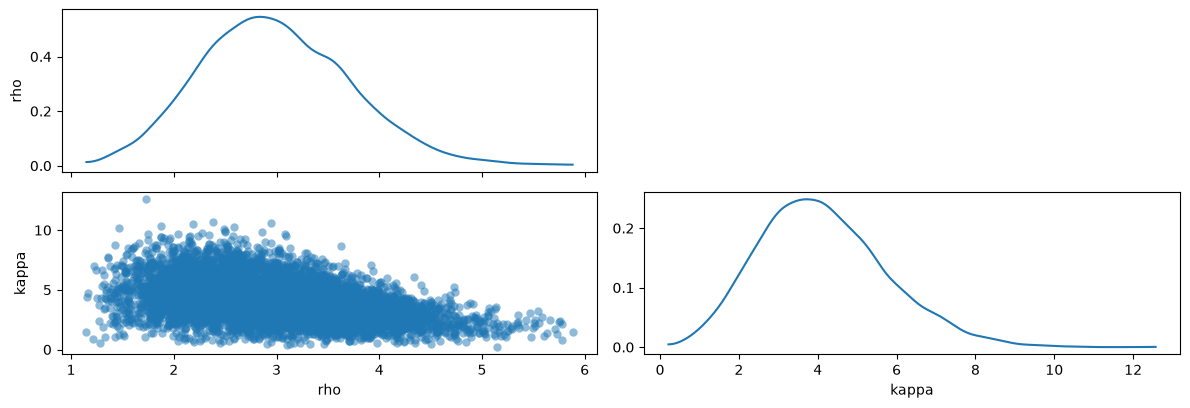

In [23]:
# Diagnostics ArviZ pour l'inference de rho et kappa
print("Diagnostics de convergence MCMC (rho, kappa)")
print("=" * 50)
summary_rho = az.summary(trace_rho, var_names=["rho", "kappa"], ci_prob=0.89, ci_kind="hdi")
print(summary_rho.to_string())

ess = az.ess(trace_rho, var_names=["rho", "kappa"])
rhat = az.rhat(trace_rho, var_names=["rho", "kappa"])
print(f"\nESS  rho={float(ess['rho'].values):.0f}  kappa={float(ess['kappa'].values):.0f}  (cible > 400)")
print(f"R-hat rho={float(rhat['rho'].values):.4f}  kappa={float(rhat['kappa'].values):.4f}  (cible < 1.01)")

plt.rcParams["figure.figsize"] = (11, 5)
az.plot_trace(trace_rho, var_names=["rho", "kappa"])
plt.tight_layout()
plt.show()

# plot_posterior retire en ArviZ 1.x : plot_dist (densite + HDI 89%) le remplace
plt.rcParams["figure.figsize"] = (11, 4)
az.plot_dist(trace_rho, var_names=["rho", "kappa"], ci_prob=0.89, ci_kind="hdi")
plt.tight_layout()
plt.show()

plt.rcParams["figure.figsize"] = (6, 5)
az.plot_pair(trace_rho, var_names=["rho", "kappa"])
plt.tight_layout()
plt.show()

Sampling: [obs]


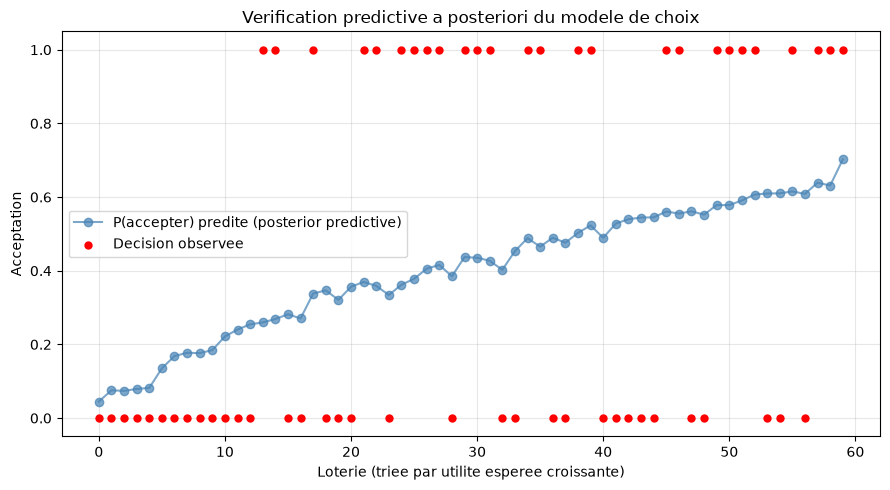

Taux d'acceptation global : observe = 0.433, predit = 0.402
Le modele reproduit le taux d'acceptation global et son ordonnancement par EU.


In [24]:
# Verification predictive a posteriori (PPC) du modele de choix
with model_rho:
    ppc = pm.sample_posterior_predictive(trace_rho, random_seed=RANDOM_SEED, progressbar=False)

obs_pred = ppc.posterior_predictive["obs"].values.reshape(-1, M)
taux_pred = obs_pred.mean(axis=0)  # taux d'acceptation predit par loterie

fig, ax = plt.subplots(figsize=(9, 5))
order = np.argsort(EU_true)
ax.plot(np.arange(M), taux_pred[order], "o-", color="steelblue", alpha=0.7,
        label="P(accepter) predite (posterior predictive)")
ax.scatter(np.arange(M), accepts[order], color="red", s=25, zorder=3,
           label="Decision observee")
ax.set_xlabel("Loterie (triee par utilite esperee croissante)")
ax.set_ylabel("Acceptation")
ax.set_title("Verification predictive a posteriori du modele de choix")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

taux_obs_global = accepts.mean()
taux_pred_global = obs_pred.mean()
print(f"Taux d'acceptation global : observe = {taux_obs_global:.3f}, predit = {taux_pred_global:.3f}")
print("Le modele reproduit le taux d'acceptation global et son ordonnancement par EU.")

### 9bis.3 Propagation de l'incertitude : posterior predictive de la prime de risque

La grande force de l'approche bayesienne est de propager l'incertitude sur $\rho$ jusqu'a une **quantite de decision** d'intérêt — ici la prime de risque d'une loterie de reference. Au lieu d'un point unique (estimation ponctuelle de $\rho$), on obtient une **distribution complete de la prime**, avec son intervalle de credibilite.

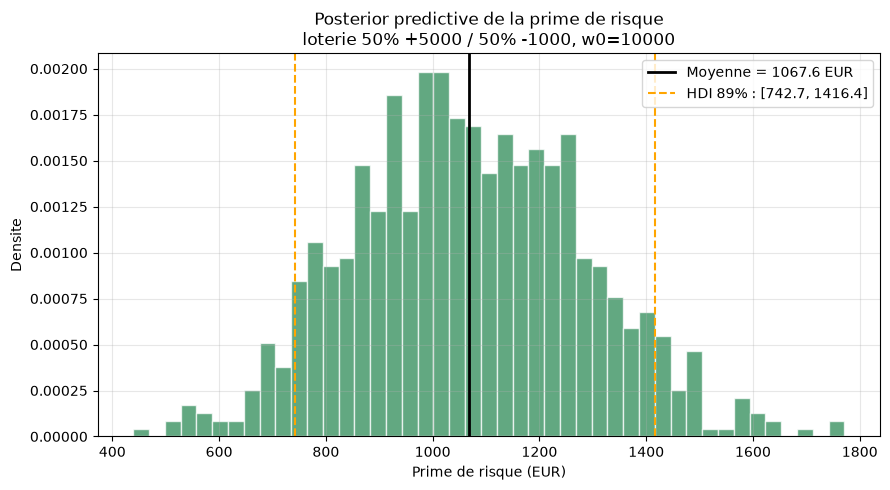

Prime de risque : estimation ponctuelle vs distribution bayesienne
Valeur esperee de la loterie       : 12000 EUR
Prime (point, rho = E[rho])        : 1082.8 EUR
Prime (bayesienne, moyenne)        : 1067.6 EUR
Prime (bayesienne, HDI 89%)        : [742.7, 1416.4] EUR
Largeur de l'incertitude (HDI)     : 673.7 EUR


In [25]:
# Posterior predictive de la prime de risque pour une loterie de reference
w0_pp = 10000
outcomes_pp = [w0_pp + 5000, w0_pp - 1000]   # meme loterie qu'en section 5
probs_pp = [0.5, 0.5]
ev_pp = sum(pr * o for pr, o in zip(probs_pp, outcomes_pp))

# Echantillonnage : prime de risque pour chaque tirage posterior de rho
idx = np.linspace(0, len(rho_post) - 1, 800).astype(int)
rho_sample = rho_post[idx]
primes_pp = np.array([
    ev_pp - compute_ce(lambda x, r=r: utilite_crra(x, r), outcomes_pp, probs_pp,
                       low=min(outcomes_pp) - 1, high=max(outcomes_pp) + 1)
    for r in rho_sample
])

hdi_lo, hdi_hi = np.percentile(primes_pp, [5.5, 94.5])
prime_point = ev_pp - compute_ce(lambda x: utilite_crra(x, rho_post.mean()),
                                 outcomes_pp, probs_pp,
                                 low=min(outcomes_pp) - 1, high=max(outcomes_pp) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(primes_pp, bins=45, density=True, alpha=0.75, color="seagreen", edgecolor="white")
ax.axvline(primes_pp.mean(), color="k", linewidth=2, label=f"Moyenne = {primes_pp.mean():.1f} EUR")
ax.axvline(hdi_lo, color="orange", linestyle="--", label=f"HDI 89% : [{hdi_lo:.1f}, {hdi_hi:.1f}]")
ax.axvline(hdi_hi, color="orange", linestyle="--")
ax.set_xlabel("Prime de risque (EUR)")
ax.set_ylabel("Densite")
ax.set_title("Posterior predictive de la prime de risque\nloterie 50% +5000 / 50% -1000, w0=10000")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Prime de risque : estimation ponctuelle vs distribution bayesienne")
print("=" * 60)
print(f"Valeur esperee de la loterie       : {ev_pp:.0f} EUR")
print(f"Prime (point, rho = E[rho])        : {prime_point:.1f} EUR")
print(f"Prime (bayesienne, moyenne)        : {primes_pp.mean():.1f} EUR")
print(f"Prime (bayesienne, HDI 89%)        : [{hdi_lo:.1f}, {hdi_hi:.1f}] EUR")
print(f"Largeur de l'incertitude (HDI)     : {hdi_hi - hdi_lo:.1f} EUR")

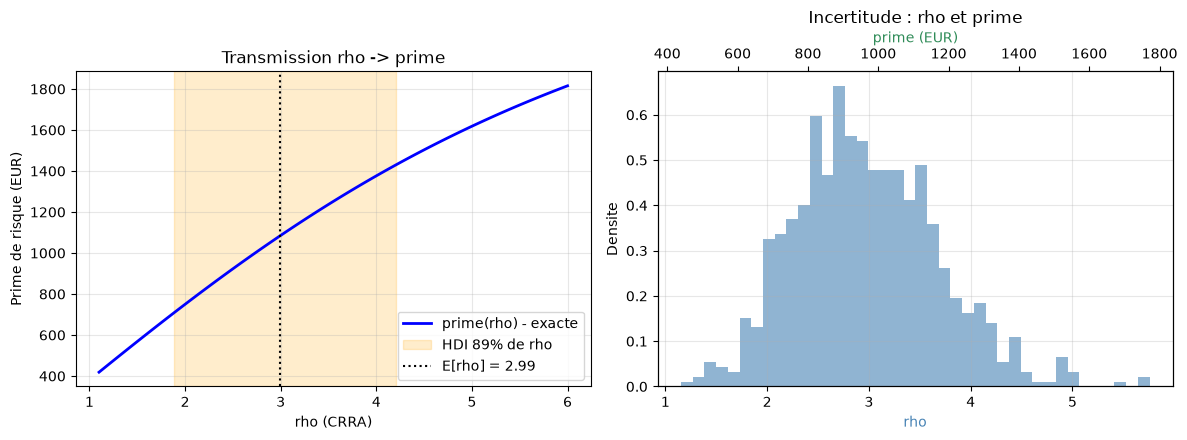

Correlation rho <-> prime (sur les tirages posterior) : 0.997
La prime est une fonction croissante de rho : l'incertitude sur l'aversion
se propage directement en incertitude sur le cout du risque.


In [26]:
# Comment l'incertitude sur rho se traduit en incertitude sur la prime
rho_axis = np.linspace(1.1, 6.0, 120)
prime_curve = np.array([
    ev_pp - compute_ce(lambda x, r=r: utilite_crra(x, r), outcomes_pp, probs_pp,
                       low=min(outcomes_pp) - 1, high=max(outcomes_pp) + 1)
    for r in rho_axis
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Gauche : courbe prime(rho) + bande issue du posterior de rho
ax1.plot(rho_axis, prime_curve, "b-", linewidth=2, label="prime(rho) - exacte")
r_lo, r_hi = np.percentile(rho_post, [5.5, 94.5])
ax1.axvspan(r_lo, r_hi, color="orange", alpha=0.2, label="HDI 89% de rho")
ax1.axvline(rho_post.mean(), color="k", linestyle=":", label=f"E[rho] = {rho_post.mean():.2f}")
ax1.set_xlabel("rho (CRRA)")
ax1.set_ylabel("Prime de risque (EUR)")
ax1.set_title("Transmission rho -> prime")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Droite : posterior de rho vs posterior predictive de la prime (densites comparees)
ax2.hist(rho_sample, bins=40, density=True, alpha=0.6, color="steelblue", label="posterior rho")
ax2b = ax2.twiny()
ax2b.hist(primes_pp, bins=40, density=True, alpha=0.4, color="seagreen", label="posterior prime")
ax2.set_xlabel("rho", color="steelblue")
ax2b.set_xlabel("prime (EUR)", color="seagreen")
ax2.set_ylabel("Densite")
ax2.set_title("Incertitude : rho et prime")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

corr = np.corrcoef(rho_sample, primes_pp)[0, 1]
print(f"Correlation rho <-> prime (sur les tirages posterior) : {corr:.3f}")
print("La prime est une fonction croissante de rho : l'incertitude sur l'aversion")
print("se propage directement en incertitude sur le cout du risque.")

**Lecture.** L'incertitude sur $\rho$ (largeur de la bande orange) se transmet a la prime de risque via la relation croissante $\pi(\rho)$. La distribution bayesienne de la prime quantifie le risque d'estimation que masque une simple estimation ponctuelle.

In [27]:
# Tableau de synthese : trois profils d'aversion sur la loterie de reference
import pandas as pd

profils = {"Audacieux": 1.3, "Modere": 2.5, "Prudent": 4.5}
lignes = []
for nom, r in profils.items():
    ce = compute_ce(lambda x, rr=r: utilite_crra(x, rr), outcomes_pp, probs_pp,
                    low=min(outcomes_pp) - 1, high=max(outcomes_pp) + 1)
    prime = ev_pp - ce
    lignes.append({
        "Profil": nom,
        "rho": r,
        "ARA(w0)=rho/w0": r / w0_pp,
        "RRA=rho": r,
        "Equivalent certain (EUR)": round(ce, 1),
        "Prime de risque (EUR)": round(prime, 1),
        "Prime / E[X] (%)": round(100 * prime / ev_pp, 2),
    })

df_synthese = pd.DataFrame(lignes).set_index("Profil")
print("Synthese : prime de risque par profil (loterie 50% +5000 / 50% -1000, w0=10000)")
print(f"Valeur esperee E[X] = {ev_pp:.0f} EUR\n")
df_synthese

Synthese : prime de risque par profil (loterie 50% +5000 / 50% -1000, w0=10000)
Valeur esperee E[X] = 12000 EUR



,rho,ARA(w0)=rho/w0,RRA=rho,Equivalent certain (EUR),Prime de risque (EUR),Prime / E[X] (%)
Profil,,,,,,
Audacieux,1.3,0.00013,1.3,11505.9,494.1,4.12
Modere,2.5,0.00025,2.5,11076.9,923.1,7.69
Prudent,4.5,0.00045,4.5,10496.7,1503.3,12.53


**Bilan de la section.** L'approche PyMC apporte trois plus-values par rapport au calcul déterministe : (1) une cartographie parametrique complete de la prime de risque, (2) l'inference *directe* du coefficient d'aversion $\rho$ a partir de comportements observes, et (3) la propagation de l'incertitude jusqu'aux quantites de decision (prime, equivalent certain), avec intervalles de credibilite. La section suivante propose un exercice d'application sur la VaR et la CVaR.

## 10. Exercice : VaR et CVaR d'un Portefeuille

### Objectif

Calculer la **Value at Risk (VaR)** (formalisee par J.P. Morgan RiskMetrics, 1996) et la **Conditional VaR (CVaR)**, une mesure de risque **coherente** au sens d'**Artzner, Delbaen, Eber & Heath (1999)** (*Coherent Measures of Risk*) d'un portefeuille a 2 actifs, pour différents niveaux de confiance.

### Rappels

- $\text{VaR}_\alpha$ : le seuil tel que $P(\text{perte} > \text{VaR}) = 1 - \alpha$
- $\text{CVaR}_\alpha$ : l'esperance de la perte conditionnellement a depasser la VaR

### Travail a realiser

1. Generer 10000 scénarios de rendement pour 2 actifs (correlation = 0.3)
2. Construire 3 portefeuilles : (100% A), (50/50), (100% B)
3. Calculer VaR et CVaR a 95% et 99% pour chaque portefeuille
4. Identifier le portefeuille optimal au sens CVaR
5. **Bonus** : Optimiser les poids du portefeuille pour minimiser le CVaR

In [28]:
# Exercice : VaR et CVaR d'un portefeuille
# Parametres des actifs
mu_A, sigma_A = 0.08, 0.15  # Actions : E=8%, sigma=15%
mu_B, sigma_B = 0.03, 0.05  # Obligations : E=3%, sigma=5%
correlation = 0.3

# A completer 1 : Generer les scenarios de rendement correles
# Hint : utiliser np.random.multivariate_normal avec la matrice de covariance
# cov_matrix = [[sigma_A**2, correlation*sigma_A*sigma_B],
#               [correlation*sigma_A*sigma_B, sigma_B**2]]

# A completer 2 : Construire les portefeuilles
# Hint : rendement_pf = w_A * r_A + w_B * r_B

# A completer 3 : Calculer VaR et CVaR
# Hint : VaR_alpha = np.percentile(pertes, alpha * 100)
# Hint : CVaR_alpha = pertes[pertes >= VaR_alpha].mean()

# A completer 4 : Comparer les portefeuilles

print("Exercice a completer : VaR et CVaR d'un portefeuille a 2 actifs.")
print("Indices : multivariate_normal pour la correlation, percentile pour la VaR.")

Exercice a completer : VaR et CVaR d'un portefeuille a 2 actifs.
Indices : multivariate_normal pour la correlation, percentile pour la VaR.


## 11. Resume

| Concept | Description |
|---------|-------------|
| **Saint-Petersbourg** | Paradoxe resolu par l'utilite marginale decroissante |
| **CARA** | Aversion absolue constante ; independent du niveau de richesse |
| **CRRA** | Aversion relative constante ; plus realiste empiriquement |
| **Arrow-Pratt** | Mesure objective de l'aversion au risque d'une fonction U |
| **Equivalent certain** | Montant garanti equivalent a une loterie : U(CE) = E[U(X)] |
| **Prime de risque** | Paiement pour eviter l'incertitude : $\pi = E[X] - CE$ |
| **Dominance stochastique** | Comparaison de loteries sans connaitre U exacte |
| **Inference bayesienne** | Estimation du profil de risque a partir de choix observes |

### Distributions utilisees dans ce notebook

| Distribution | Paramètres | Usage typique |
|--------------|------------|---------------|
| **Beta** | (alpha, beta) | Prior/posterior sur une probabilite (profil de risque) |
| **Bernoulli** | (p,) | Decisions binaires (choix risque/securite) |
| **Normale** | (mu, sigma) | Modèle de rendement financier |

---

## Pour aller plus loin

| Si vous voulez... | Consultez... |
|-------------------|-------------|
| Multi-attributs et compromis | [DecPyMC-3-Multi-Attribute](DecPyMC-3-Multi-Attribute.ipynb) |
| Reseaux de decision | [DecPyMC-4-Decision-Networks](DecPyMC-4-Decision-Networks.ipynb) |

## References

**Théorie de la decision et aversion au risque**
- Bernoulli, D. (1738) : *Specimen Theoriae Novae de Mensura Sortis* (paradoxe de Saint-Petersbourg, utilite logarithmique)
- Bernoulli, N. (1713) : lettre a Montmort (formulation du paradoxe)
- Von Neumann, J. & Morgenstern, O. (1944) : *Theory of Games and Economic Behavior* (axiomes VNM, utilite esperee)
- Pratt, J. W. (1964) : *Risk Aversion in the Small and in the Large*, Econometrica 32:122-136 (coefficients ARA/RRA, prime de risque)
- Arrow, K. J. (1965) : *Aspects of the Theory of Risk-Bearing (CARA/CRRA)
- Markowitz, H. (1952) : *Portfolio Sélection*, Journal of Finance 7:77-91 (mean-variance, frontiere efficiente)
- Hadar, J. & Russell, W. (1969) ; Hanoch, G. & Levy, H. (1969) : dominance stochastique du premier ordre
- Artzner, P., Delbaen, F., Eber, J.-M. & Heath, D. (1999) : *Coherent Measures of Risk*, Mathematical Finance 9:203-228 (VaR/CVaR)
- Kahneman, D. & Tversky, A. (1979) : *Prospect Theory*, Econometrica (limites descriptives de l'utilite esperee)

**Implementation**
- Salvatier, J., Wiecki, T. V. & Fonnesbeck, C. (2016) : *Probabilistic programming in Python using PyMC3*, PeerJ Computer Science
- Kumar, R. et al. (2019) : *ArviZ: a unified library for exploratory analysis of Bayesian models in Python*, JOSS
- Russell, S. & Norvig, P. : *Artificial Intelligence: A Modern Approach*, chapitre 16